# Uplift Modeling EDA — Magnit Tech × НИУ ВШЭ 2026

**Цель**: понять данные, проверить гипотезы, сохранить артефакты для пилота.

**Структура:**
1. Установка зависимостей
2. Загрузка данных
3. Обзор датасета (shape, nulls, duplicates)
4. Анализ таргета `rec_spend`
5. Баланс T/C по `communication_type`
6. **Гипотеза 1**: разные аплифты по каналу
7. **Гипотеза 2**: сегментация клиентов и природа аплифтов
8. Дистрибуции ключевых фичей (T vs C, KS-тест)
9. Корреляции с таргетом (Spearman, T=1 vs T=0)
10. Treatment-ассоциированные фичи (метод Скалотех)
11. Baseline T-learner: feature importance + SHAP
12. Baseline uplift-кривые
13. Сохранение артефактов для пилота

## 0. Установка зависимостей

In [1]:
%%bash
pip install -q lightgbm scikit-uplift shap scipy pyarrow pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3.14 -m pip install --upgrade pip


In [21]:
!pip install scikit-uplift


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3.14 -m pip install --upgrade pip


## 1. Импорты и конфиги

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import shap
import json
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ARTIFACTS_DIR = 'eda_artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Imports OK')


Imports OK


## 2. Загрузка данных

In [3]:
train = pd.read_parquet('train.parquet')
test  = pd.read_parquet('test.parquet')

desc_df = pd.read_csv('data_description.csv', sep=';').dropna(subset=['feature'])
feat_desc = dict(zip(desc_df['feature'], desc_df['desc']))

TREATMENT_COL = 'treatment_flg'
TARGET_COL    = 'rec_spend'
COMM_COL      = 'communication_type'
ID_COL        = 'user_id'
FEATURE_COLS  = [c for c in train.columns if c not in [ID_COL, TREATMENT_COL, TARGET_COL]]

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'Feature cols: {len(FEATURE_COLS)}')
display(train.head(3))


Train: (355246, 89)  |  Test: (118414, 87)
Feature cols: 86


,user_id,communication_type,treatment_flg,rec_spend,age,n_days_life,gendercalc,n_plastic_card,n_virtual_card,rto,...,cus_cat_5_last_2_3_days,cus_cat_5_max_min_days_diff,cus_cat_5_last_1_days,cus_cat_5_last_2_days,cus_cat_5_last_3_days,cus_mark_fav_cat_accept_flg_1_month_ago,cus_mark_fav_cat_accept_flg_2_month_ago,cus_mark_n_offers,cus_mark_n_view,cus_mark_n_rule
0,272706,com_type_1,1,0.0,31.0,1848.0,0.0,1.0,1.0,7010.0,...,14.0,303.0,15.0,69.0,83.0,1.0,1.0,32.0,14.0,2.0
1,314387,com_type_1,0,0.0,36.0,1713.0,1.0,1.0,1.0,17049.0,...,NaN,10.0,18.0,28.0,NaN,1.0,NaN,60.0,8.0,1.0
2,104701,com_type_3,1,0.0,15.0,136.0,0.0,NaN,1.0,20811.0,...,NaN,54.0,8.0,62.0,NaN,NaN,1.0,78.0,17.0,4.0


In [51]:
import warnings, json, time, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

from sklift.metrics import uplift_at_k, qini_auc_score
from sklift.metrics import uplift_curve, qini_curve

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Constants ──────────────────────────────────────────────────────────────────
RANDOM_STATE   = 42
N_FOLDS        = 5
ARTIFACTS_DIR  = 'pilot_artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

TARGET_COL    = 'rec_spend'
TREATMENT_COL = 'treatment_flg'
ID_COL        = 'user_id'
COMM_COL      = 'communication_type'

COMM_TYPES    = ['com_type_1', 'com_type_2', 'com_type_3']

# TOP-25 из EDA feature importance
TOP25 = [
    'cus_cat_7_rto', 'n_redeem', 'cus_cat_7_atv', 'cus_cat_5_rto',
    'cus_cat_5_std', 'mntv', 'n_days_life', 'cus_cat_5_atv',
    'cus_cat_7_n_days_big_period', 'cus_cat_7_std', 'cus_mark_n_offers',
    'cus_cat_6_rto', 'rto_format_1', 'age', 'cus_mark_n_view', 'n_sku',
    'cus_cat_6_std', 'cus_cat_6_atv', 'cus_cat_5_max_min_days_diff',
    'cus_mark_n_rule', 'p_25_tv', 'cus_cat_7_max_min_days_diff',
    'mxtv', 'rto_format_3', 'avg_days_btw_trn'
]

print('✅ Config loaded')
print(f'Artifacts dir: {ARTIFACTS_DIR}/')

✅ Config loaded
Artifacts dir: pilot_artifacts/


In [ ]:
шь
# ═══ SUBMISSION: Multi-seed blend (perchan*0.7 + global*0.3) ═════════════════
print('Training multi-seed blend submission...')
t0 = time.time()

SEEDS = [42, 137, 271, 512, 999]

# ── Параметры уже найдены Optuna ──────────────────────────────────────────────
# best_params1_xl, best_params2_xl, best_prop_xl, best_feat_xl  — из глобальной
# channel_params  — из per-channel (dict: ch -> {params1, params2, prop, feat})

def build_params_with_seed(base_params, seed):
    """Заменяем только random_state, остальное не трогаем."""
    p = base_params.copy()
    p['random_state'] = seed
    return p

# ── Глобальная модель: 5 сидов ────────────────────────────────────────────────
print('\n[Global XL] Multi-seed inference...')
global_test_scores_list = []

for seed in SEEDS:
    print(f'  seed={seed}...', end=' ', flush=True)
    p1 = build_params_with_seed(best_params1_xl, seed)
    p2 = build_params_with_seed(best_params2_xl, seed)

    X_tr = encode_X(train, best_feat_xl)
    X_te = encode_X(test,  best_feat_xl)
    m1 = T == 1; m0 = T == 0

    mu1 = lgb.LGBMRegressor(**p1); mu0 = lgb.LGBMRegressor(**p1)
    mu1.fit(X_tr[m1], y[m1]); mu0.fit(X_tr[m0], y[m0])

    D1 = y[m1] - mu0.predict(X_tr[m1])
    D0 = mu1.predict(X_tr[m0]) - y[m0]

    tau1 = lgb.LGBMRegressor(**p2); tau0 = lgb.LGBMRegressor(**p2)
    tau1.fit(X_tr[m1], D1); tau0.fit(X_tr[m0], D0)

    if best_prop_xl == 'logreg':
        g = LogisticRegression(max_iter=500, C=1.0, n_jobs=-1)
    else:
        g = lgb.LGBMClassifier(n_estimators=200, num_leaves=31,
                                n_jobs=-1, random_state=seed, verbose=-1)
    g.fit(X_tr, T)
    g_te = g.predict_proba(encode_X(test, best_feat_xl))[:, 1]

    scores = g_te * tau0.predict(X_te) + (1 - g_te) * tau1.predict(X_te)
    global_test_scores_list.append(scores)
    print(f'mean={scores.mean():.3f}')

# Усредняем по рангам (стабильнее чем среднее сырых скоров)
global_test_scores_ms = np.mean(
    [rankdata(s) for s in global_test_scores_list], axis=0
)
print(f'Global multi-seed done. mean_rank={global_test_scores_ms.mean():.1f}')

# ── Per-channel модель: 5 сидов ───────────────────────────────────────────────
print('\n[Per-Channel XL] Multi-seed inference...')
perchan_test_scores_list = []

for seed in SEEDS:
    print(f'  seed={seed}...')
    seed_scores = np.zeros(len(test))
    comm_test = test[COMM_COL].values
    comm_train = train[COMM_COL].values

    for ch in COMM_CODES:
        cp        = channel_params[ch]
        feat_cols = FEAT_COLS if cp['feat'] == 'all' else FEAT_COLS_TOP

        ch_tr = comm_train == ch
        ch_te = comm_test  == ch
        df_ch_tr = train[ch_tr].reset_index(drop=True)
        df_ch_te = test[ch_te].reset_index(drop=True)
        y_ch = y[ch_tr]; T_ch = T[ch_tr]
        m1 = T_ch == 1; m0 = T_ch == 0

        p1 = build_params_with_seed(cp['params1'], seed)
        p2 = build_params_with_seed(cp['params2'], seed)

        X_tr = encode_X(df_ch_tr, feat_cols)
        X_te = encode_X(df_ch_te, feat_cols)

        mu1 = lgb.LGBMRegressor(**p1); mu0 = lgb.LGBMRegressor(**p1)
        mu1.fit(X_tr[m1], y_ch[m1]); mu0.fit(X_tr[m0], y_ch[m0])

        D1 = y_ch[m1] - mu0.predict(X_tr[m1])
        D0 = mu1.predict(X_tr[m0]) - y_ch[m0]

        tau1 = lgb.LGBMRegressor(**p2); tau0 = lgb.LGBMRegressor(**p2)
        tau1.fit(X_tr[m1], D1); tau0.fit(X_tr[m0], D0)

        if cp['prop'] == 'logreg':
            g = LogisticRegression(max_iter=500, C=1.0, n_jobs=-1)
        else:
            g = lgb.LGBMClassifier(n_estimators=200, num_leaves=31,
                                   n_jobs=-1, random_state=seed, verbose=-1)
        g.fit(X_tr, T_ch)
        g_te = g.predict_proba(X_te)[:, 1]

        seed_scores[ch_te] = (
            g_te * tau0.predict(X_te) + (1 - g_te) * tau1.predict(X_te)
        )
        print(f'    ch={ch}: mean={seed_scores[ch_te].mean():.3f}')

    perchan_test_scores_list.append(seed_scores)

perchan_test_scores_ms = np.mean(
    [rankdata(s) for s in perchan_test_scores_list], axis=0
)
print(f'Per-channel multi-seed done. mean_rank={perchan_test_scores_ms.mean():.1f}')

# ── Финальный бленд 0.7 perchan + 0.3 global ─────────────────────────────────
# Ранги уже усреднены внутри каждой модели, теперь бленд между ними
blend_final = 0.7 * rankdata(perchan_test_scores_ms) + \
              0.3 * rankdata(global_test_scores_ms)

submission_final = pd.DataFrame({
    'user_id':      test['user_id'],
    'UPLIFT_SCORE': blend_final
})
sub_path_final = f'{ARTIFACTS_DIR}/submission_multiseed_blend_07_03.csv'
submission_final.to_csv(sub_path_final, index=False)

elapsed = time.time() - t0
print(f'\n✅ Saved: {sub_path_final}')
print(f'   elapsed={elapsed:.0f}s  ({elapsed/60:.1f} min)')
print(f'   score stats: min={blend_final.min():.1f}  '
      f'max={blend_final.max():.1f}  mean={blend_final.mean():.1f}')

# Сохраняем компоненты отдельно (на случай переблендинга)
np.save(f'{ARTIFACTS_DIR}/test_global_ms.npy',  global_test_scores_ms)
np.save(f'{ARTIFACTS_DIR}/test_perchan_ms.npy', perchan_test_scores_ms)
print('   Components saved: test_global_ms.npy, test_perchan_ms.npy')

Training multi-seed blend submission...


NameError: name 'time' is not defined

## 3. Обзор датасета

In [4]:
print('=== DTYPES ===')
display(train.dtypes.value_counts().rename('count').to_frame())

print('\n=== DUPLICATES ===')
print(f'Dup user_id train: {train[ID_COL].duplicated().sum()}')
print(f'Dup user_id test:  {test[ID_COL].duplicated().sum()}')

print('\n=== NULL ANALYSIS ===')
null_df = pd.DataFrame({
    'null_count': train.isnull().sum(),
    'null_pct':   (train.isnull().mean() * 100).round(2)
})
null_nz = null_df[null_df['null_count'] > 0].sort_values('null_pct', ascending=False)
print(f'Колонок с пропусками: {len(null_nz)}')
if len(null_nz) > 0:
    display(null_nz)
null_df.to_csv(f'{ARTIFACTS_DIR}/null_counts.csv')

print('\n=== DESCRIBE ===')
desc_stats = train[FEATURE_COLS + [TARGET_COL]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
desc_stats.to_csv(f'{ARTIFACTS_DIR}/describe_stats.csv')
display(desc_stats.head(15))


=== DTYPES ===


,count
float64,86
int64,1
str,1
int32,1



=== DUPLICATES ===
Dup user_id train: 0
Dup user_id test:  0

=== NULL ANALYSIS ===
Колонок с пропусками: 85


,null_count,null_pct
cus_cat_7_std,284108,79.98
cus_cat_6_std,276211,77.75
rto_format_2,261583,73.63
cus_cat_7_rto,214765,60.46
cus_cat_7_atv,214765,60.46
...,...,...
mtv,13,0.00
atv,13,0.00
rto,13,0.00
n_virtual_card,7,0.00



=== DESCRIBE ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,355237.0,38.769951,13.279615,5.0,16.0,19.0,30.0,37.0,47.0,62.0,71.00,156.0
n_days_life,355005.0,1371.386566,549.515103,42.0,110.0,247.0,973.0,1664.0,1793.0,1911.0,2004.00,2152.0
gendercalc,343923.0,0.241778,0.428161,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.00,1.0
n_plastic_card,257949.0,1.274329,0.544401,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.00,11.0
n_virtual_card,355239.0,1.015280,0.135695,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.00,7.0
rto,355233.0,12075.451146,9119.883992,-219.0,783.0,2040.6,5881.0,10320.0,15814.0,28076.0,45655.00,496493.0
atv,355233.0,781.432308,570.498237,-24.0,156.0,242.6,426.0,628.0,950.0,1838.0,2954.00,14644.0
mtv,355233.0,640.937914,541.976583,-760.0,106.0,170.0,320.0,493.0,771.0,1610.0,2808.00,15791.0
p_25_tv,355229.0,395.414789,377.187951,-2359.0,59.0,97.0,185.0,292.0,475.0,1020.0,1912.00,13976.0
p_75_tv,355233.0,1006.128077,785.081708,31.0,177.0,287.0,526.0,789.0,1217.0,2472.0,4062.68,17704.0


## 4. Анализ таргета `rec_spend`

Доля нулей (все):    90.2%
Доля нулей (T=1):    89.6%
Доля нулей (T=0):    90.7%
Mean T=1: 22.7496  |  Mean T=0: 19.5601
Raw global uplift: 3.1895
Mann-Whitney U (T1>T0): p=8.4255e-30


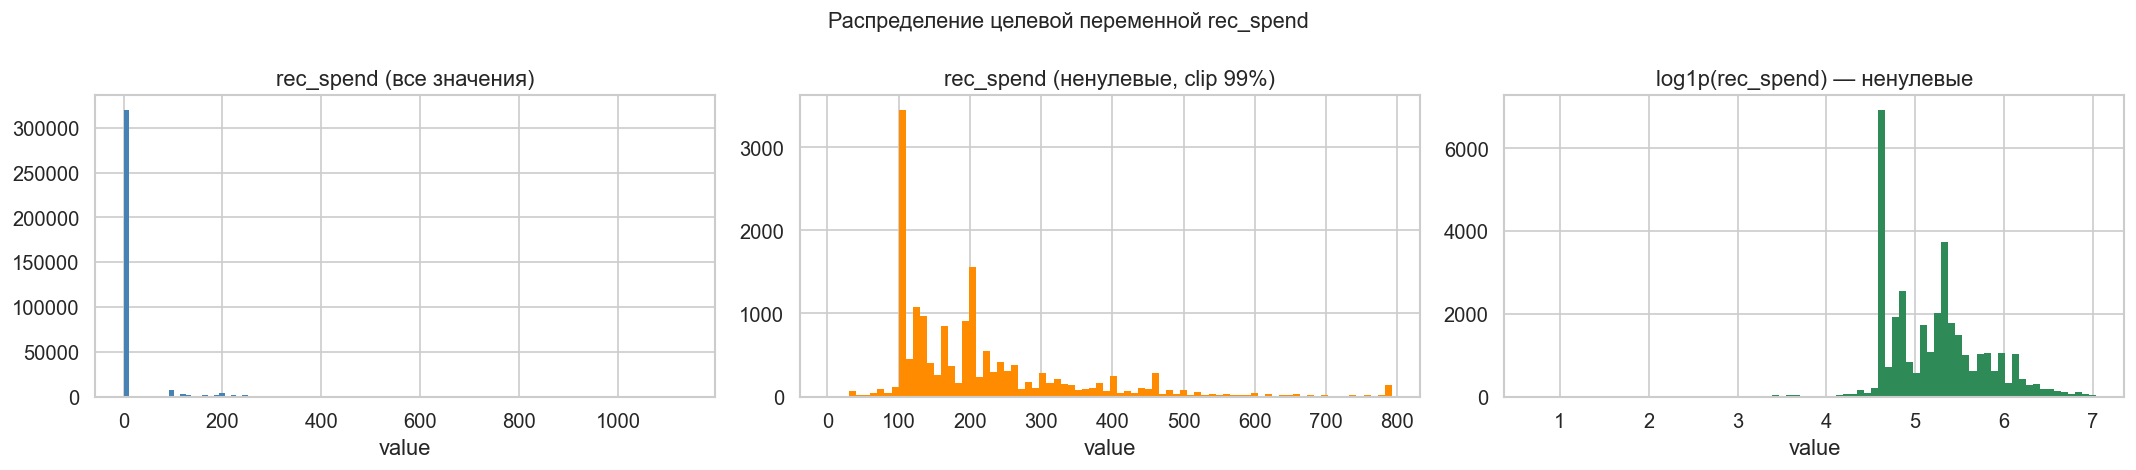

Saved: global_stats.json


In [32]:
zero_pct = (train[TARGET_COL] == 0).mean() * 100
nonzero  = train.loc[train[TARGET_COL] > 0, TARGET_COL]
t1_vals  = train.loc[train[TREATMENT_COL] == 1, TARGET_COL]
t0_vals  = train.loc[train[TREATMENT_COL] == 0, TARGET_COL]

print(f'Доля нулей (все):    {zero_pct:.1f}%')
print(f'Доля нулей (T=1):    {(t1_vals == 0).mean()*100:.1f}%')
print(f'Доля нулей (T=0):    {(t0_vals == 0).mean()*100:.1f}%')
print(f'Mean T=1: {t1_vals.mean():.4f}  |  Mean T=0: {t0_vals.mean():.4f}')
print(f'Raw global uplift: {t1_vals.mean() - t0_vals.mean():.4f}')
_, p_mw = mannwhitneyu(t1_vals, t0_vals, alternative='greater')
print(f'Mann-Whitney U (T1>T0): p={p_mw:.4e}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(train[TARGET_COL], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('rec_spend (все значения)')
axes[1].hist(nonzero[train[TREATMENT_COL] == 0].clip(upper=nonzero.quantile(0.99)), bins=80, color='darkorange', edgecolor='none')
axes[1].set_title('rec_spend (ненулевые, clip 99%)')
axes[2].hist(np.log1p(nonzero), bins=80, color='seagreen', edgecolor='none')
axes[2].set_title('log1p(rec_spend) — ненулевые')
for ax in axes:
    ax.set_xlabel('value')
plt.suptitle('Распределение целевой переменной rec_spend', fontsize=13)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/target_distribution.png', bbox_inches='tight')
plt.show()

global_stats = {
    'n_train': int(len(train)), 'n_test': int(len(test)),
    'n_treatment': int((train[TREATMENT_COL]==1).sum()),
    'n_control':   int((train[TREATMENT_COL]==0).sum()),
    'target_zero_pct':    float(zero_pct),
    'target_zero_pct_t1': float((t1_vals==0).mean()*100),
    'target_zero_pct_t0': float((t0_vals==0).mean()*100),
    'mean_t1': float(t1_vals.mean()),
    'mean_t0': float(t0_vals.mean()),
    'raw_global_uplift': float(t1_vals.mean() - t0_vals.mean()),
    'mannwhitney_p': float(p_mw),
}
with open(f'{ARTIFACTS_DIR}/global_stats.json', 'w') as f:
    json.dump(global_stats, f, indent=2)
print('Saved: global_stats.json')


In [29]:
train["rec_spend"].mean()

np.float64(21.140558852175676)

## 5. Баланс T/C и `communication_type`

In [46]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# ── Пути ─────────────────────────────────────────────────────────────────────
ARTIFACTS_DIR = 'pilot_artifacts'  # вставь свой путь
TARGET_COL    = 'rec_spend'
TREATMENT_COL = 'treatment_flg'
COMM_COL      = 'communication_type'
RANDOM_STATE  = 42

# ── Загружаем данные ──────────────────────────────────────────────────────────

y = train[TARGET_COL].values
T = train[TREATMENT_COL].values
comm = train[COMM_COL].values
COMM_CODES = sorted(train[COMM_COL].unique())

# ── Загружаем OOF ─────────────────────────────────────────────────────────────
oof_global   = np.load(f'{ARTIFACTS_DIR}/oof_xlearner_opt.npy')
oof_perchan  = np.load(f'{ARTIFACTS_DIR}/oof_perchan_xl_opt.npy')

# ch2-only: занулить каналы 0 и 1
CH_STAR = COMM_CODES[2]  # канал с uplift@10=28.70
oof_ch2_only = np.zeros(len(train))
ch2_mask = (comm == CH_STAR)
oof_ch2_only[ch2_mask] = oof_perchan[ch2_mask]

# ── uplift@k (твоя реализация) ────────────────────────────────────────────────
# вставь свою функцию если она уже определена в ноуте
# def uplift_at_k_spend(y, score, T, k=0.1): ...
def uplift_at_k_spend(y_spend, uplift_scores, treatment, k=0.1):
    """
    uplift@k по непрерывному rec_spend:
    E[rec_spend | T=1, top-k%] - E[rec_spend | T=0, top-k%]
    """
    n = len(y_spend)
    top_n = max(int(n * k), 1)
    
    # Берём индексы топ-k% по uplift score
    top_idx = np.argsort(uplift_scores)[::-1][:top_n]
    
    t_mask  = treatment[top_idx] == 1
    c_mask  = treatment[top_idx] == 0
    
    if t_mask.sum() == 0 or c_mask.sum() == 0:
        return 0.0
    
    return float(y_spend[top_idx][t_mask].mean() - y_spend[top_idx][c_mask].mean())
# ── Bootstrap CI ──────────────────────────────────────────────────────────────
def bootstrap_uplift(y, score, T, k=0.1, n_boot=500, ci_lo=10, ci_hi=90, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        stats.append(uplift_at_k_spend(y[idx], score[idx], T[idx], k=k))
    stats = np.array(stats)
    return np.mean(stats), np.percentile(stats, ci_lo), np.percentile(stats, ci_hi)


# ── Все варианты для сравнения ────────────────────────────────────────────────
candidates = {
    'global XL':    oof_global,
    'perchan XL':   oof_perchan,
    'ch2-only XL':  oof_ch2_only,
}

# Бленды perchan + global
for w in [0.3, 0.5, 0.7]:
    blend = w * rankdata(oof_perchan) + (1 - w) * rankdata(oof_global)
    candidates[f'blend perchan*{w:.1f}+global*{1-w:.1f}'] = blend

# Бленды ch2-only + global
for w in [0.6, 0.7, 0.8, 0.9]:
    blend = w * rankdata(oof_ch2_only) + (1 - w) * rankdata(oof_global)
    candidates[f'blend ch2*{w:.1f}+global*{1-w:.1f}'] = blend

# ── Считаем ───────────────────────────────────────────────────────────────────
print(f'\n{"Модель":<40} {"uplift@10":>10} {"CI80_lo":>10} {"CI80_hi":>10}')
print('-' * 72)

results = {}
for name, score in candidates.items():
    mean, lo, hi = bootstrap_uplift(y, score, T, k=0.1, n_boot=500)
    results[name] = (mean, lo, hi)
    print(f'{name:<40} {mean:>10.4f} {lo:>10.4f} {hi:>10.4f}')

# ── Per-channel breakdown для ch2-only ───────────────────────────────────────
print('\nPer-channel breakdown (ch2-only):')
for ch in COMM_CODES:
    mask = (comm == ch)
    u_ch = uplift_at_k_spend(y[mask], oof_ch2_only[mask], T[mask], k=0.1)
    n_nonzero = (oof_ch2_only[mask] != 0).sum()
    print(f'  ch={ch}: uplift@10={u_ch:.4f}  ненулевых скоров={n_nonzero:,}')

# ── Диагностика: сколько клиентов из каждого канала попадает в топ-10% ────────
print('\nСостав топ-10% по каналам:')
n_top = int(0.1 * len(train))
for name, score in [('global XL', oof_global),
                     ('perchan XL', oof_perchan),
                     ('ch2-only XL', oof_ch2_only)]:
    top_mask = score >= np.sort(score)[::-1][n_top]
    print(f'\n  {name}:')
    for ch in COMM_CODES:
        n_ch_top = ((comm == ch) & top_mask).sum()
        print(f'    ch={ch}: {n_ch_top:,} ({n_ch_top/n_top*100:.1f}% топа)')

# ── Лучший кандидат ───────────────────────────────────────────────────────────
best_name = max(results, key=lambda x: results[x][1])  # по нижней границе CI
best_mean, best_lo, best_hi = results[best_name]
print(f'\n✅ Лучший по нижней границе CI80:')
print(f'   {best_name}: {best_mean:.4f}  CI80=[{best_lo:.4f}, {best_hi:.4f}]')


Модель                                    uplift@10    CI80_lo    CI80_hi
------------------------------------------------------------------------
global XL                                   21.0508    19.3702    22.7471
perchan XL                                  20.6628    18.9187    22.4934
ch2-only XL                                 12.2131    10.9194    13.5995
blend perchan*0.3+global*0.7                21.2283    19.6150    22.7585
blend perchan*0.5+global*0.5                20.8853    19.2883    22.5181
blend perchan*0.7+global*0.3                21.3086    19.6560    22.9066
blend ch2*0.6+global*0.4                    12.8647    11.6030    14.1854
blend ch2*0.7+global*0.3                    12.6518    11.3366    13.9084
blend ch2*0.8+global*0.2                    12.4729    11.1699    13.7390
blend ch2*0.9+global*0.1                    12.2987    10.9014    13.6469

Per-channel breakdown (ch2-only):
  ch=com_type_1: uplift@10=3.7576  ненулевых скоров=0
  ch=com_type_2: uplift

In [49]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# ── Загружаем тестовые скоры ──────────────────────────────────────────────────
sub_perchan = pd.read_csv(f'{ARTIFACTS_DIR}/submission_perchan_xl_opt.csv')
sub_global  = pd.read_csv(f'{ARTIFACTS_DIR}/submission_xl_opt.csv')  # имя глобального сабмита

# Проверяем что user_id совпадает
assert (sub_perchan['user_id'].values == sub_global['user_id'].values).all(), \
    'user_id не совпадают!'

scores_perchan = sub_perchan['UPLIFT_SCORE'].values
scores_global  = sub_global['UPLIFT_SCORE'].values

# ── Бленд 0.7 perchan + 0.3 global по рангу ──────────────────────────────────
# Важно: rankdata применяем к тесту, а не к трейну
blend_test = 0.7 * rankdata(scores_perchan) + 0.3 * rankdata(scores_global)

submission_blend = pd.DataFrame({
    'user_id':      sub_perchan['user_id'],
    'UPLIFT_SCORE': blend_test
})

sub_path_blend = f'{ARTIFACTS_DIR}/submission_blend_perchan07_global03.csv'
submission_blend.to_csv(sub_path_blend, index=False)
print(f'✅ Saved: {sub_path_blend}')
print(f'   n={len(submission_blend):,}')
print(f'   score stats: min={blend_test.min():.1f}  max={blend_test.max():.1f}  mean={blend_test.mean():.1f}')

# Быстрая проверка: распределение по каналам в топ-10% теста
n_top = int(0.1 * len(test))
top_mask = blend_test >= np.sort(blend_test)[::-1][n_top]
print(f'\nСостав топ-10% теста ({n_top:,} клиентов):')
for ch in sorted(test[COMM_COL].unique()):
    n_ch = ((test[COMM_COL] == ch) & top_mask).sum()
    print(f'  ch={ch}: {n_ch:,} ({n_ch/n_top*100:.1f}%)')

✅ Saved: pilot_artifacts/submission_blend_perchan07_global03.csv
   n=118,414
   score stats: min=5.7  max=118412.8  mean=59207.5

Состав топ-10% теста (11,841 клиентов):
  ch=com_type_1: 3,980 (33.6%)
  ch=com_type_2: 2,866 (24.2%)
  ch=com_type_3: 4,996 (42.2%)


In [41]:
train[[ID_COL, COMM_COL, "gendercalc"]].groupby([ID_COL, COMM_COL], as_index=False).agg("count").sort_values("gendercalc", ascending=False)

,user_id,communication_type,gendercalc
0,1,com_type_1,1
234867,234868,com_type_1,1
234875,234876,com_type_2,1
234874,234875,com_type_1,1
234873,234874,com_type_1,1
...,...,...,...
271127,271128,com_type_2,0
271125,271126,com_type_2,0
344809,344810,com_type_2,0
10096,10097,com_type_3,0


Communication types: ['com_type_1', 'com_type_2', 'com_type_3']


,n_control,n_treatment,pct_control,pct_treatment,total
communication_type,,,,,
com_type_1,59720,58589,0.505,0.495,118309
com_type_2,59633,58833,0.503,0.497,118466
com_type_3,59861,58610,0.505,0.495,118471


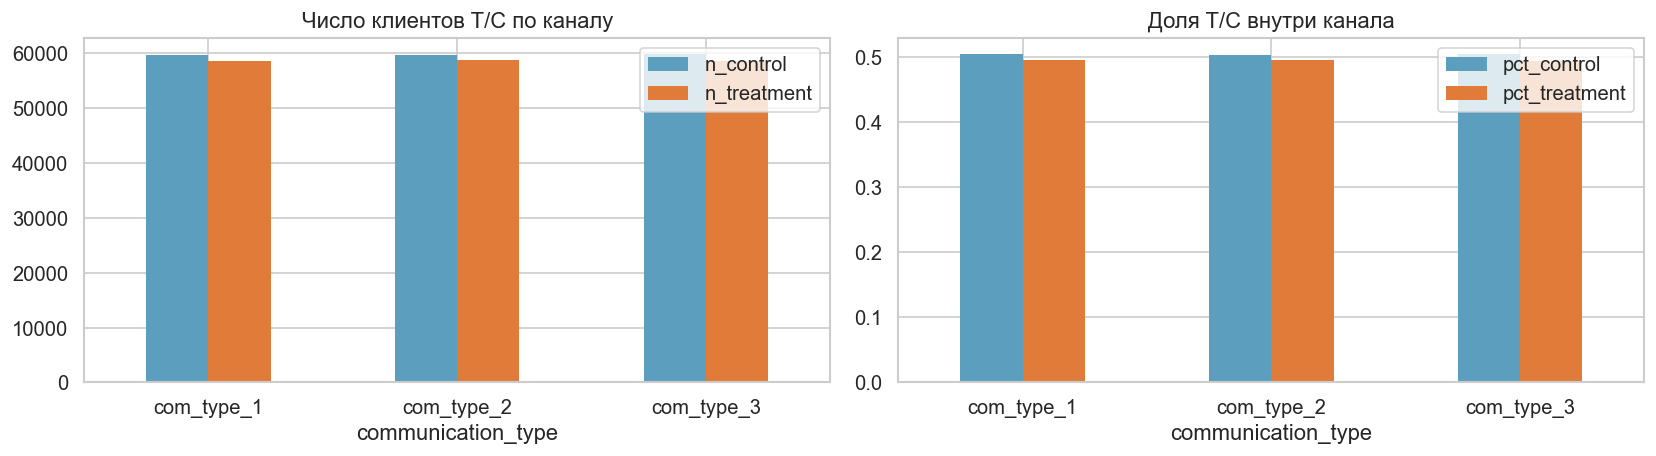

In [6]:
comm_types = sorted(train[COMM_COL].unique())
print(f'Communication types: {comm_types}')

tc_counts = train.groupby(COMM_COL)[TREATMENT_COL].value_counts().unstack().fillna(0)
tc_pct    = train.groupby(COMM_COL)[TREATMENT_COL].value_counts(normalize=True).unstack().fillna(0)
tc_counts.columns = ['n_control', 'n_treatment']
tc_pct.columns    = ['pct_control', 'pct_treatment']
tc_full = pd.concat([tc_counts, tc_pct], axis=1)
tc_full['total'] = tc_full['n_control'] + tc_full['n_treatment']
display(tc_full.round(3))
tc_full.to_csv(f'{ARTIFACTS_DIR}/tc_balance_by_comm_type.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tc_counts.plot(kind='bar', ax=axes[0], color=['#5c9ebe', '#e07b39'], edgecolor='none')
axes[0].set_title('Число клиентов T/C по каналу')
axes[0].tick_params(axis='x', rotation=0)
tc_pct.plot(kind='bar', ax=axes[1], color=['#5c9ebe', '#e07b39'], edgecolor='none')
axes[1].set_title('Доля T/C внутри канала')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/tc_balance_comm.png', bbox_inches='tight')
plt.show()


## 6. Гипотеза 1: Разные аплифты по `communication_type`

Для каждого канала: mean(T=1) − mean(T=0), bootstrap 80% CI (500 итераций), Mann-Whitney тест.
Также hurdle-декомпозиция: изменение P(buy) vs изменение среднего чека при покупке.

In [7]:
uplift_by_comm = []
for ct in comm_types:
    sub  = train[train[COMM_COL] == ct]
    t1_  = sub.loc[sub[TREATMENT_COL] == 1, TARGET_COL]
    t0_  = sub.loc[sub[TREATMENT_COL] == 0, TARGET_COL]
    uplift_mean = t1_.mean() - t0_.mean()
    rng = np.random.default_rng(RANDOM_STATE)
    boots = [rng.choice(t1_.values, len(t1_), replace=True).mean() -
             rng.choice(t0_.values, len(t0_), replace=True).mean()
             for _ in range(500)]
    ci_lo, ci_hi = np.percentile(boots, [10, 90])
    _, p = mannwhitneyu(t1_, t0_, alternative='two-sided')
    prob_uplift = (t1_ > 0).mean() - (t0_ > 0).mean()
    spend_t1 = t1_[t1_ > 0].mean() if (t1_ > 0).sum() > 0 else 0.0
    spend_t0 = t0_[t0_ > 0].mean() if (t0_ > 0).sum() > 0 else 0.0
    uplift_by_comm.append({
        'communication_type': ct,
        'n_treatment': len(t1_), 'n_control': len(t0_),
        'mean_t1': t1_.mean(), 'mean_t0': t0_.mean(),
        'uplift_mean': uplift_mean, 'ci80_lo': ci_lo, 'ci80_hi': ci_hi,
        'zero_pct_t1': (t1_==0).mean()*100, 'zero_pct_t0': (t0_==0).mean()*100,
        'prob_buy_uplift': prob_uplift,
        'avg_spend_uplift_given_buy': spend_t1 - spend_t0,
        'mannwhitney_p': p,
    })

uplift_comm_df = pd.DataFrame(uplift_by_comm)
uplift_comm_df.to_csv(f'{ARTIFACTS_DIR}/uplift_by_comm_type.csv', index=False)
display(uplift_comm_df.round(4))


,communication_type,n_treatment,n_control,mean_t1,mean_t0,uplift_mean,ci80_lo,ci80_hi,zero_pct_t1,zero_pct_t0,prob_buy_uplift,avg_spend_uplift_given_buy,mannwhitney_p
0,com_type_1,58589,59720,23.1732,19.3950,3.7781,3.2742,4.3455,89.4400,90.8356,0.014,7.8092,0.0000
1,com_type_2,58833,59633,21.3100,19.8874,1.4226,0.8624,2.0480,90.0413,90.6444,0.006,1.4108,0.0004
2,com_type_3,58610,59861,23.7712,19.3988,4.3724,3.7668,5.0094,89.4643,90.7636,0.013,15.5986,0.0000


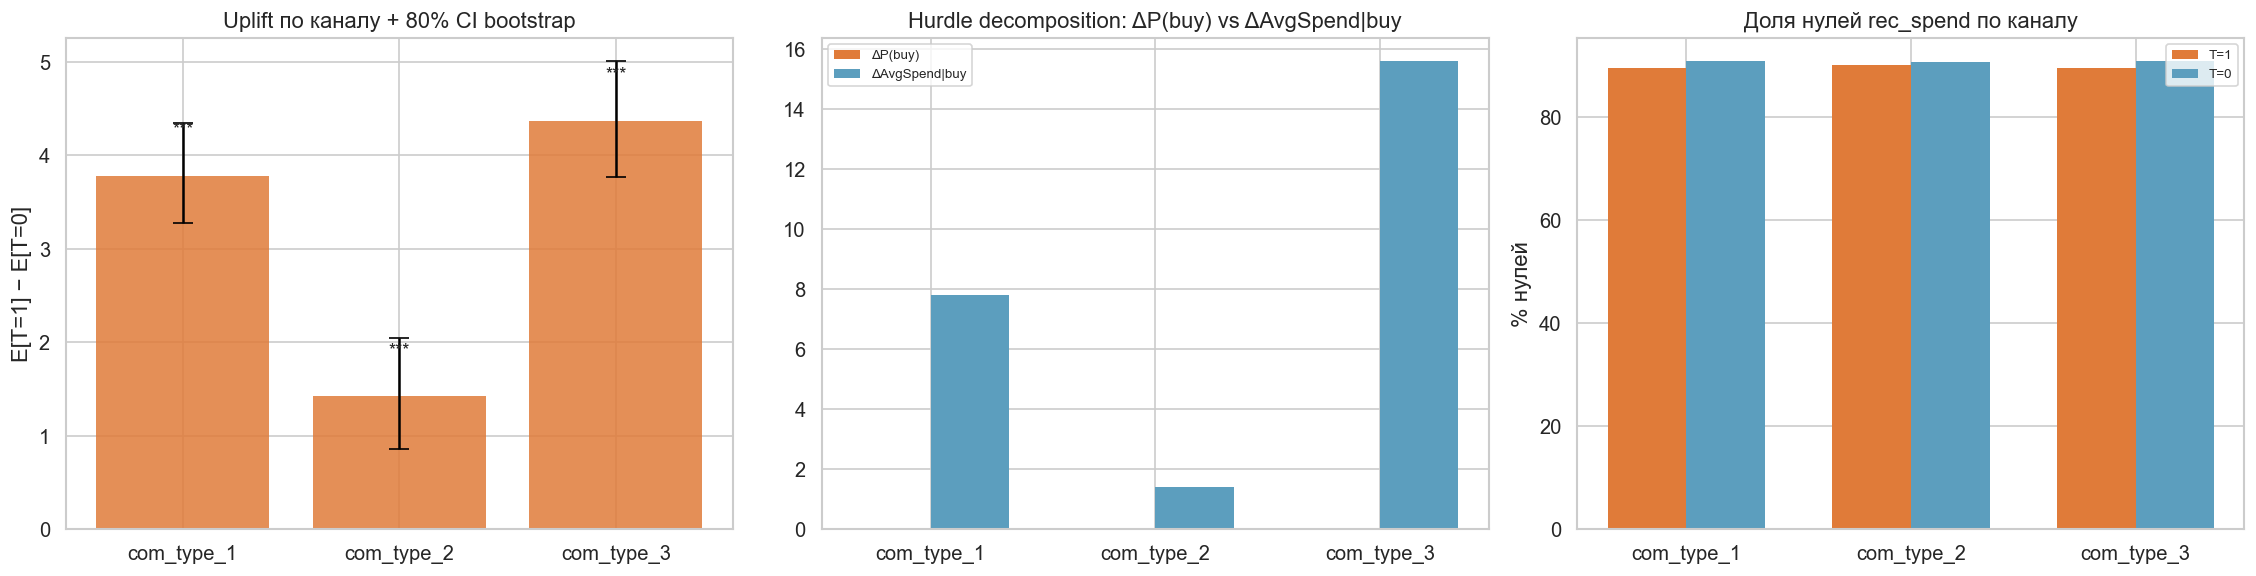


=== ВЫВОД ===
  comm=com_type_1: uplift=3.7781 [3.2742, 4.3455]  ✅ значим  (p=2.533e-16)
  comm=com_type_2: uplift=1.4226 [0.8624, 2.0480]  ✅ значим  (p=4.183e-04)
  comm=com_type_3: uplift=4.3724 [3.7668, 5.0094]  ✅ значим  (p=6.706e-15)

Макс. разрыв между каналами: 2.9498
→ РЕКОМЕНДУЕТСЯ делать отдельные модели per communication_type


In [8]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
x   = [str(c) for c in uplift_comm_df['communication_type']]
y   = uplift_comm_df['uplift_mean'].values
elo = y - uplift_comm_df['ci80_lo'].values
ehi = uplift_comm_df['ci80_hi'].values - y
xi  = np.arange(len(x))
bw  = 0.35

# 1: uplift + CI
axes[0].bar(x, y, color=['#e07b39' if v>=0 else '#5c9ebe' for v in y], edgecolor='none', alpha=0.85)
axes[0].errorbar(x, y, yerr=[elo, ehi], fmt='none', color='black', capsize=6, lw=1.5)
axes[0].axhline(0, color='black', ls='--', lw=0.8)
axes[0].set_title('Uplift по каналу + 80% CI bootstrap')
axes[0].set_ylabel('E[T=1] − E[T=0]')
for j, pv in enumerate(uplift_comm_df['mannwhitney_p']):
    star = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
    axes[0].text(j, y[j] + max(abs(y))*0.1, star, ha='center', fontsize=11)

# 2: hurdle decomposition
axes[1].bar(xi-bw/2, uplift_comm_df['prob_buy_uplift'], bw,
            label='ΔP(buy)', color='#e07b39', edgecolor='none')
axes[1].bar(xi+bw/2, uplift_comm_df['avg_spend_uplift_given_buy'], bw,
            label='ΔAvgSpend|buy', color='#5c9ebe', edgecolor='none')
axes[1].set_xticks(xi); axes[1].set_xticklabels(x)
axes[1].axhline(0, color='black', ls='--', lw=0.8)
axes[1].set_title('Hurdle decomposition: ΔP(buy) vs ΔAvgSpend|buy')
axes[1].legend(fontsize=8)

# 3: zero %
axes[2].bar(xi-bw/2, uplift_comm_df['zero_pct_t1'], bw, label='T=1', color='#e07b39', edgecolor='none')
axes[2].bar(xi+bw/2, uplift_comm_df['zero_pct_t0'], bw, label='T=0', color='#5c9ebe', edgecolor='none')
axes[2].set_xticks(xi); axes[2].set_xticklabels(x)
axes[2].set_title('Доля нулей rec_spend по каналу')
axes[2].set_ylabel('% нулей'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/uplift_by_comm_type.png', bbox_inches='tight')
plt.show()

print('\n=== ВЫВОД ===')
for r in uplift_comm_df.itertuples():
    sig = '✅ значим' if r.mannwhitney_p < 0.05 else '⚠️  незначим'
    print(f'  comm={r.communication_type}: uplift={r.uplift_mean:.4f} '
          f'[{r.ci80_lo:.4f}, {r.ci80_hi:.4f}]  {sig}  (p={r.mannwhitney_p:.3e})')

max_diff = uplift_comm_df['uplift_mean'].max() - uplift_comm_df['uplift_mean'].min()
print(f'\nМакс. разрыв между каналами: {max_diff:.4f}')
rec = ('РЕКОМЕНДУЕТСЯ делать отдельные модели per communication_type'
       if max_diff > 0.01
       else 'ДОСТАТОЧНО добавить communication_type как фичу')
print(f'→ {rec}')

with open(f'{ARTIFACTS_DIR}/hypothesis1_comm_type.json', 'w') as f:
    json.dump({
        'separate_models_recommended': bool(max_diff > 0.01),
        'max_uplift_diff': float(max_diff),
        'by_channel': uplift_comm_df.round(4).to_dict(orient='records')
    }, f, indent=2, default=str)


## 7. Гипотеза 2: Сегментация клиентов и природа аплифтов

5 сегментаций: активность (rto), аффинити к категории, рецентность, возраст, маркетинговая отзывчивость.

In [11]:
df = train.copy()

df['rto_segment'] = pd.qcut(
    df['rto'].clip(upper=df['rto'].quantile(0.99)), q=4,
    labels=['low', 'mid_low', 'mid_high', 'high'])

df['cat7_affinity'] = df['cus_cat_7_rto'] / (df['rto'] + 1e-6)
df['cat7_seg'] = pd.qcut(
    df['cat7_affinity'].clip(upper=df['cat7_affinity'].quantile(0.99)), q=4,
    labels=['no_affinity', 'low', 'medium', 'high'])

df['recency_seg'] = pd.cut(
    df['cus_cat_7_last_1_days'].fillna(999),
    bins=[-1, 7, 30, 90, float('inf')],
    labels=['<7d', '7-30d', '30-90d', '>90d'])

df['age_seg'] = pd.cut(
    df['age'].fillna(df['age'].median()),
    bins=[0, 25, 35, 50, 65, 120],
    labels=['<25', '25-35', '35-50', '50-65', '65+'])

# mkt_resp_rate: полностью robustная версия без qcut
df['mkt_resp_rate'] = df['cus_mark_n_rule'] / (df['cus_mark_n_offers'].clip(lower=1))
mkt = df['mkt_resp_rate'].clip(upper=df['mkt_resp_rate'].quantile(0.99))
zero_pct_mkt = (mkt == 0).mean()
print(f'Доля нулей в mkt_resp_rate: {zero_pct_mkt:.1%}')

p33 = mkt[mkt > 0].quantile(0.5)  # медиана ненулевых
df['mkt_seg'] = pd.cut(
    mkt,
    bins=[-0.001, 0, p33, float('inf')],
    labels=['never_resp', 'low_resp', 'high_resp']
)

SEGMENTS = {
    'rto_segment': 'Активность (траты)',
    'cat7_seg':    'Аффинити к категории',
    'recency_seg': 'Рецентность в категории',
    'age_seg':     'Возраст',
    'mkt_seg':     'Маркетинговая отзывчивость',
}
print('Сегменты созданы')

def uplift_by_segment(df, seg_col, n_boot=300):
    results = []
    cats = (df[seg_col].cat.categories if hasattr(df[seg_col], 'cat')
            else sorted(df[seg_col].dropna().unique()))
    for seg_val in cats:
        sub = df[df[seg_col] == seg_val].dropna(subset=[TREATMENT_COL, TARGET_COL])
        t1_ = sub.loc[sub[TREATMENT_COL]==1, TARGET_COL]
        t0_ = sub.loc[sub[TREATMENT_COL]==0, TARGET_COL]
        if len(t1_) < 20 or len(t0_) < 20:
            continue
        uplift_m = t1_.mean() - t0_.mean()
        rng = np.random.default_rng(RANDOM_STATE)
        boots = [rng.choice(t1_.values, len(t1_), replace=True).mean() -
                 rng.choice(t0_.values, len(t0_), replace=True).mean()
                 for _ in range(n_boot)]
        ci_lo, ci_hi = np.percentile(boots, [10, 90])
        _, p = mannwhitneyu(t1_, t0_, alternative='two-sided')
        results.append({'segment': str(seg_val), 'n': len(sub),
                        'n_t1': len(t1_), 'n_t0': len(t0_),
                        'mean_t1': t1_.mean(), 'mean_t0': t0_.mean(),
                        'uplift': uplift_m, 'ci80_lo': ci_lo, 'ci80_hi': ci_hi,
                        'p_value': p,
                        'zero_pct_t1': (t1_==0).mean()*100,
                        'zero_pct_t0': (t0_==0).mean()*100})
    return pd.DataFrame(results)

all_seg = {}
for seg_col, seg_name in SEGMENTS.items():
    sdf = uplift_by_segment(df, seg_col)
    all_seg[seg_col] = sdf
    sdf.to_csv(f'{ARTIFACTS_DIR}/uplift_seg_{seg_col}.csv', index=False)
    print(f'  ✅ {seg_name}: {len(sdf)} сегментов')

Доля нулей в mkt_resp_rate: 47.4%
Сегменты созданы
  ✅ Активность (траты): 4 сегментов
  ✅ Аффинити к категории: 4 сегментов
  ✅ Рецентность в категории: 4 сегментов
  ✅ Возраст: 5 сегментов
  ✅ Маркетинговая отзывчивость: 3 сегментов


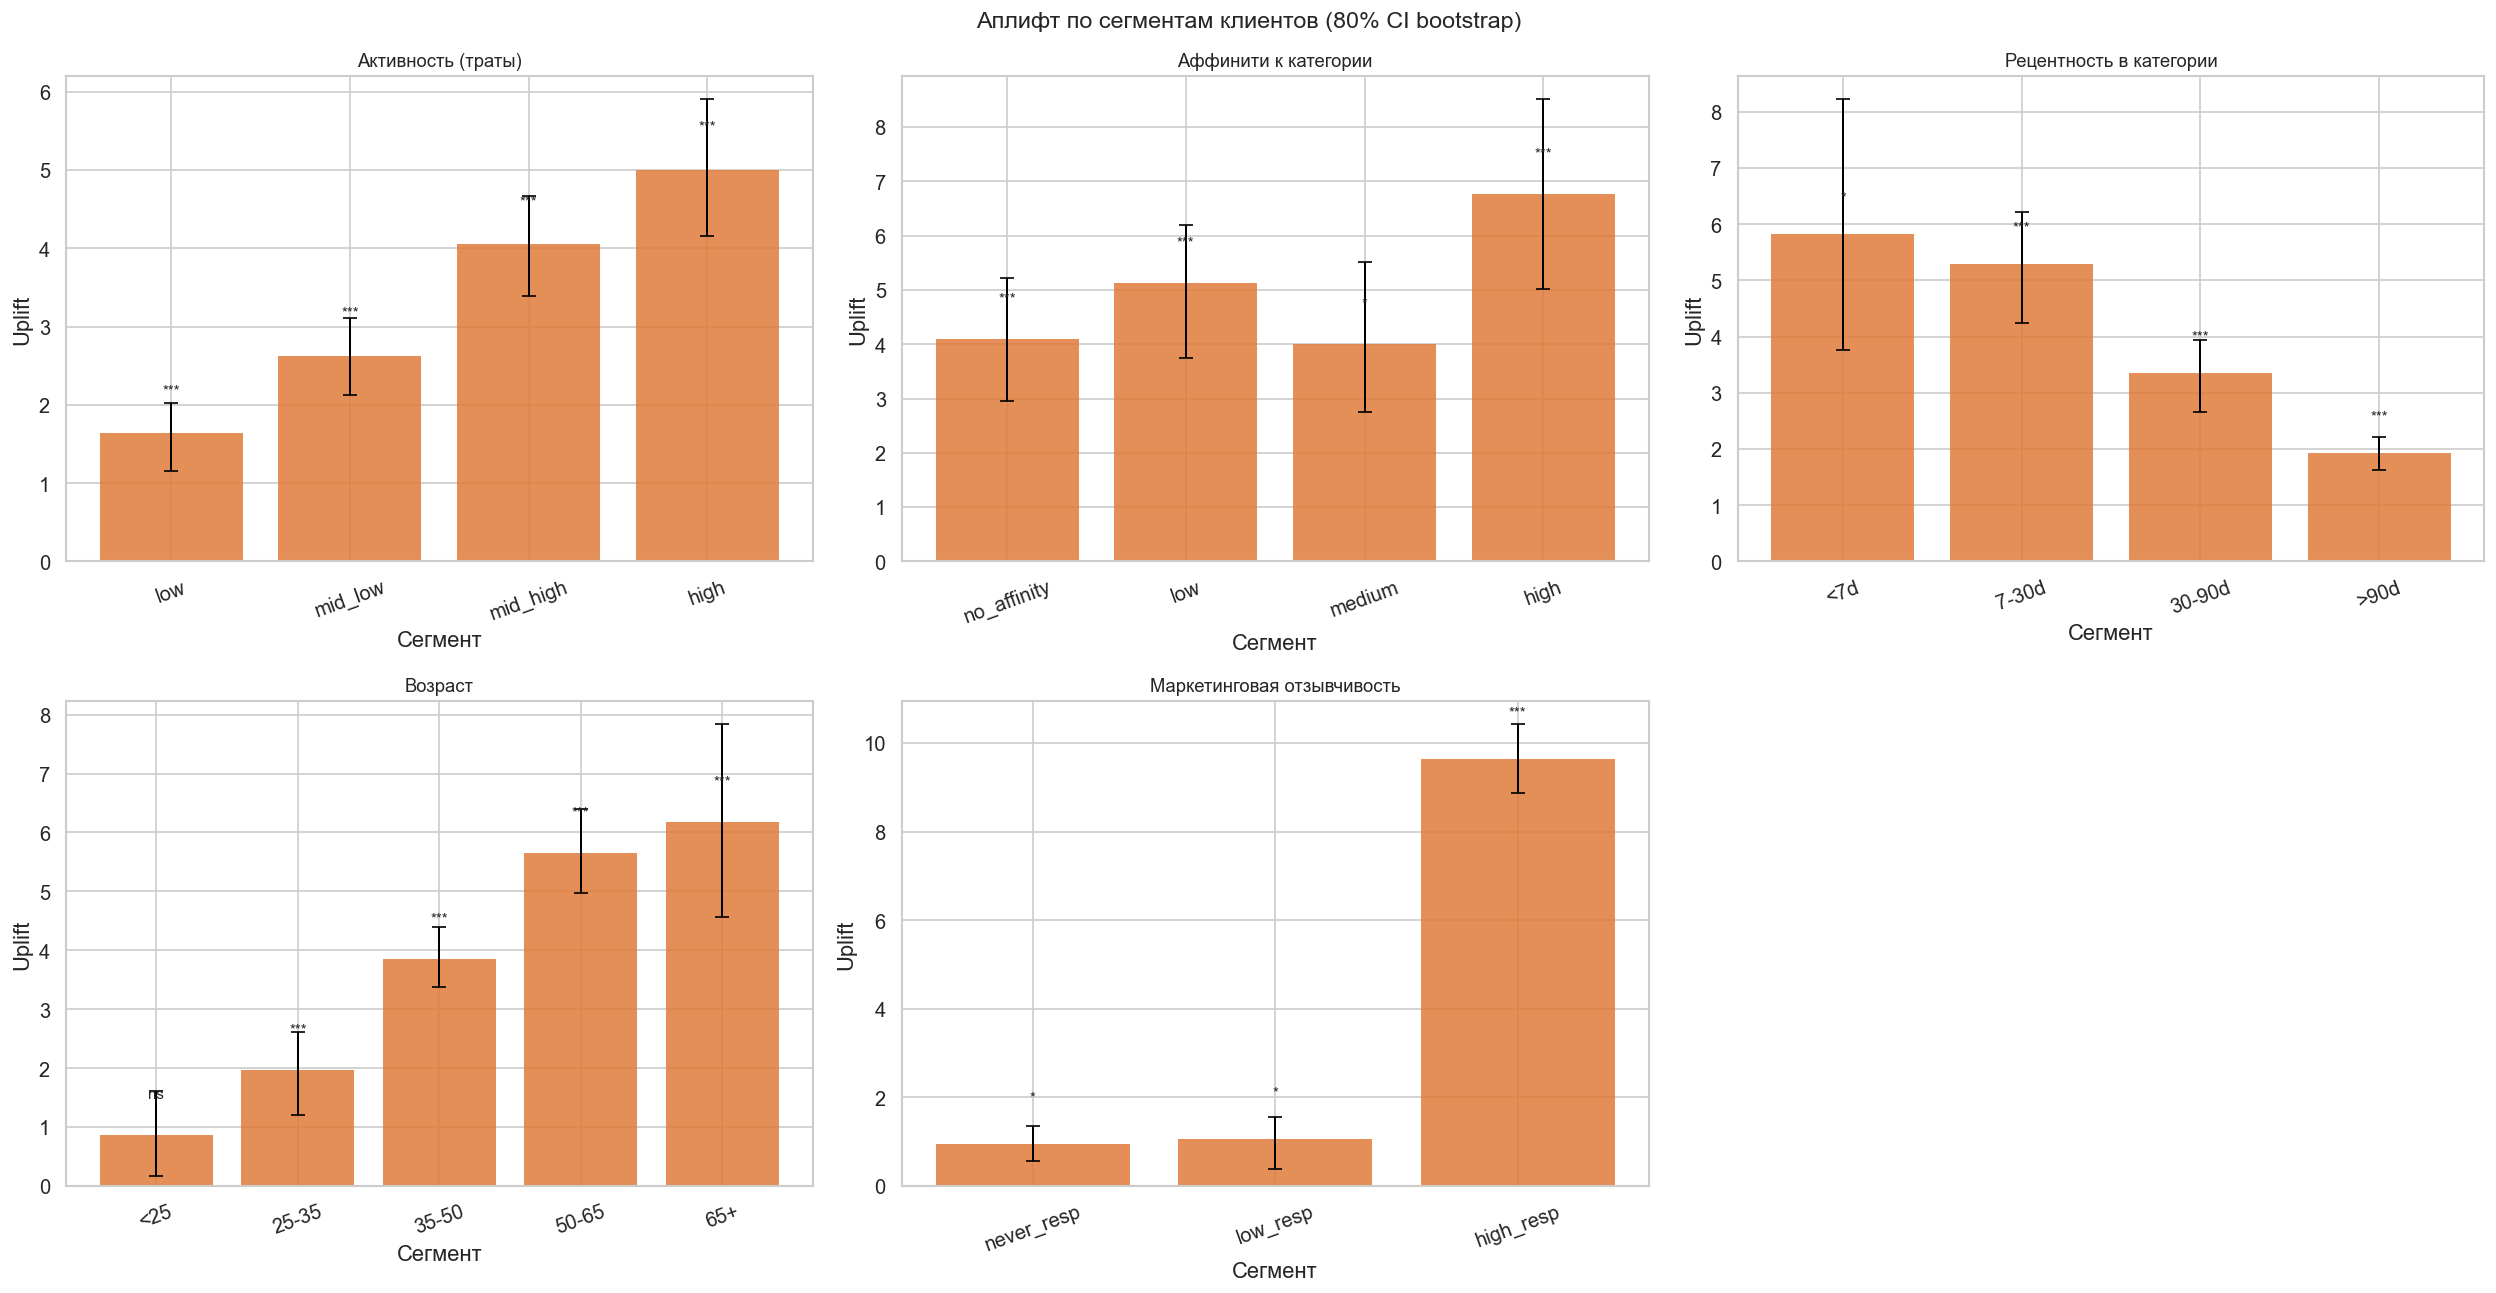


=== ВЫВОД: Гетерогенность аплифта по сегментам ===
  Активность (траты): range=3.3618 → HIGH
  Аффинити к категории: range=2.7492 → HIGH
  Рецентность в категории: range=3.9009 → HIGH
  Возраст: range=5.3114 → HIGH
  Маркетинговая отзывчивость: range=8.6976 → HIGH


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(21, 11))
axes_flat = axes.flatten()

for i, (seg_col, seg_name) in enumerate(SEGMENTS.items()):
    ax  = axes_flat[i]
    sdf = all_seg[seg_col]
    if sdf.empty:
        ax.set_visible(False); continue
    x_ = sdf['segment'].tolist()
    y_ = sdf['uplift'].values
    elo_ = y_ - sdf['ci80_lo'].values
    ehi_ = sdf['ci80_hi'].values - y_
    ax.bar(x_, y_, color=['#e07b39' if v>=0 else '#5c9ebe' for v in y_],
           edgecolor='none', alpha=0.85)
    ax.errorbar(x_, y_, yerr=[elo_, ehi_], fmt='none', color='black', capsize=4, lw=1.2)
    ax.axhline(0, color='black', ls='--', lw=0.7)
    ax.set_title(seg_name, fontsize=11)
    ax.set_xlabel('Сегмент'); ax.set_ylabel('Uplift')
    ax.tick_params(axis='x', rotation=20)
    for j_, (yv_, p_) in enumerate(zip(y_, sdf['p_value'])):
        star_ = '***' if p_<0.001 else ('**' if p_<0.01 else ('*' if p_<0.05 else 'ns'))
        off_ = max(abs(y_)) * 0.1
        ax.text(j_, yv_ + (off_ if yv_>=0 else -off_*1.8), star_, ha='center', fontsize=9)

axes_flat[-1].set_visible(False)
plt.suptitle('Аплифт по сегментам клиентов (80% CI bootstrap)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/uplift_by_segments.png', bbox_inches='tight')
plt.show()

print('\n=== ВЫВОД: Гетерогенность аплифта по сегментам ===')
hyp2 = {}
for seg_col, seg_name in SEGMENTS.items():
    sdf = all_seg[seg_col]
    if sdf.empty: continue
    rng_ = sdf['uplift'].max() - sdf['uplift'].min()
    het  = 'HIGH' if rng_ > 0.02 else ('MEDIUM' if rng_ > 0.005 else 'LOW')
    print(f'  {seg_name}: range={rng_:.4f} → {het}')
    hyp2[seg_col] = {'uplift_range': float(rng_), 'heterogeneity': het,
                     'data': sdf.round(4).to_dict(orient='records')}

with open(f'{ARTIFACTS_DIR}/hypothesis2_segments.json', 'w') as f:
    json.dump(hyp2, f, indent=2, default=str)


## 8. Дистрибуции ключевых фичей: T vs C (KS-тест)

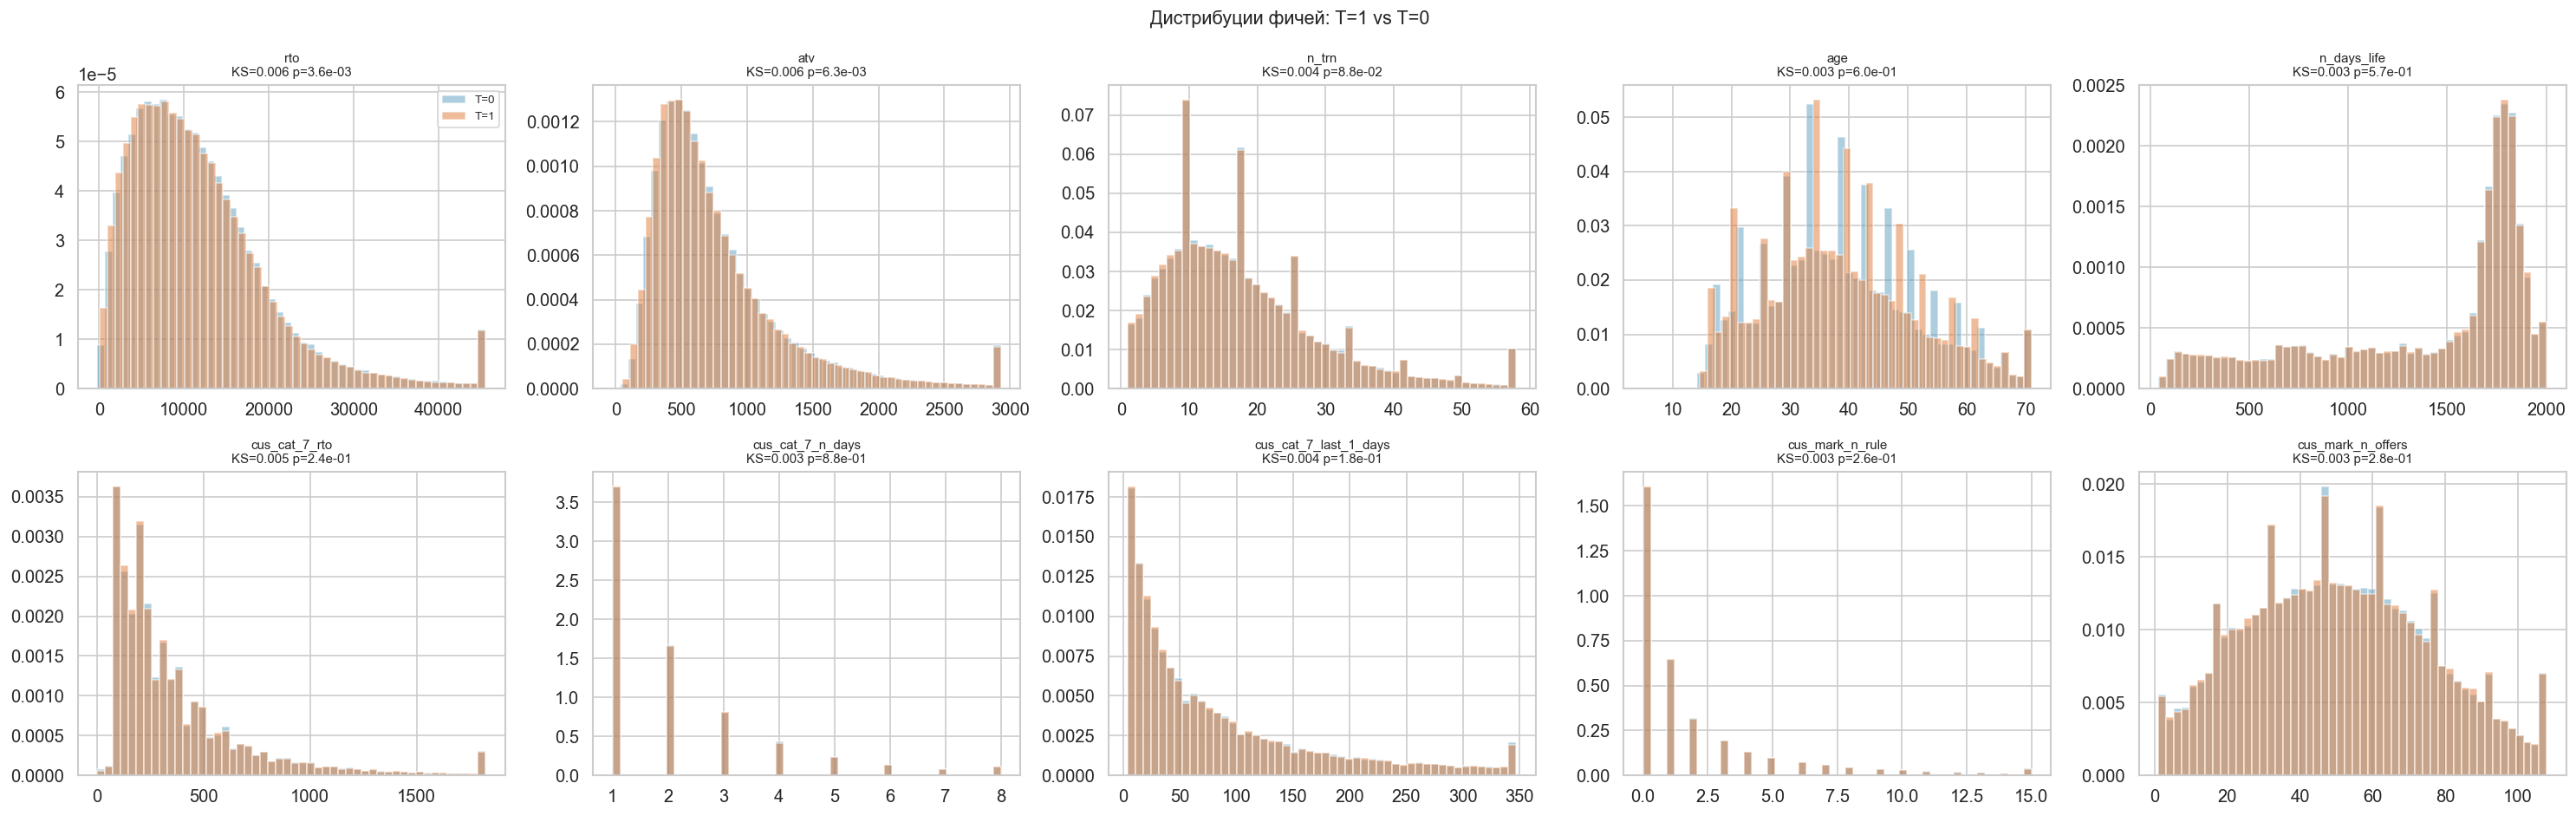

KS-тест (чем больше ks_stat — тем сильнее различие T/C):


,feature,ks_stat,ks_p
0,rto,0.005966,0.003584
1,atv,0.005695,0.006274
5,cus_cat_7_rto,0.005476,0.242087
7,cus_cat_7_last_1_days,0.004261,0.182910
2,n_trn,0.004192,0.087962
8,cus_mark_n_rule,0.003397,0.264515
9,cus_mark_n_offers,0.003338,0.283310
6,cus_cat_7_n_days,0.003132,0.879623
4,n_days_life,0.002638,0.566538
3,age,0.002574,0.597531


In [13]:
key_features = ['rto', 'atv', 'n_trn', 'age', 'n_days_life',
                'cus_cat_7_rto', 'cus_cat_7_n_days', 'cus_cat_7_last_1_days',
                'cus_mark_n_rule', 'cus_mark_n_offers']
key_features = [f for f in key_features if f in train.columns]

ks_results = []
fig, axes = plt.subplots(2, 5, figsize=(25, 8))
for i, feat in enumerate(key_features):
    ax  = axes.flatten()[i]
    t1_ = train.loc[train[TREATMENT_COL]==1, feat].dropna()
    t0_ = train.loc[train[TREATMENT_COL]==0, feat].dropna()
    clip_ = min(t1_.quantile(0.99), t0_.quantile(0.99))
    ax.hist(t0_.clip(upper=clip_), bins=50, alpha=0.5, label='T=0', color='#5c9ebe', density=True)
    ax.hist(t1_.clip(upper=clip_), bins=50, alpha=0.5, label='T=1', color='#e07b39', density=True)
    ks_s, ks_p = ks_2samp(t1_, t0_)
    ks_results.append({'feature': feat, 'ks_stat': ks_s, 'ks_p': ks_p})
    ax.set_title(f'{feat}\nKS={ks_s:.3f} p={ks_p:.1e}', fontsize=9)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Дистрибуции фичей: T=1 vs T=0', fontsize=13)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/feature_distributions_tc.png', bbox_inches='tight')
plt.show()

ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)
ks_df.to_csv(f'{ARTIFACTS_DIR}/ks_test_tc_balance.csv', index=False)
print('KS-тест (чем больше ks_stat — тем сильнее различие T/C):')
display(ks_df)


## 9. Корреляции с `rec_spend` (Spearman): T=1 vs T=0

Топ-20 фичей по разнице corr(T=1) vs corr(T=0) — потенциальные uplift-драйверы:


,corr_t1,corr_t0,diff_abs
n_redeem,0.1231,0.0846,0.0385
cus_mark_n_rule,0.1280,0.0919,0.0361
cus_mark_n_view,0.1071,0.0740,0.0331
age,-0.0086,-0.0281,0.0195
p_75_tv,0.0417,0.0611,0.0194
mtv,0.0328,0.0521,0.0193
p_25_tv,0.0157,0.0340,0.0183
mntv,-0.0509,-0.0329,0.0180
atv,0.0383,0.0559,0.0175
n_trn,0.1440,0.1267,0.0172


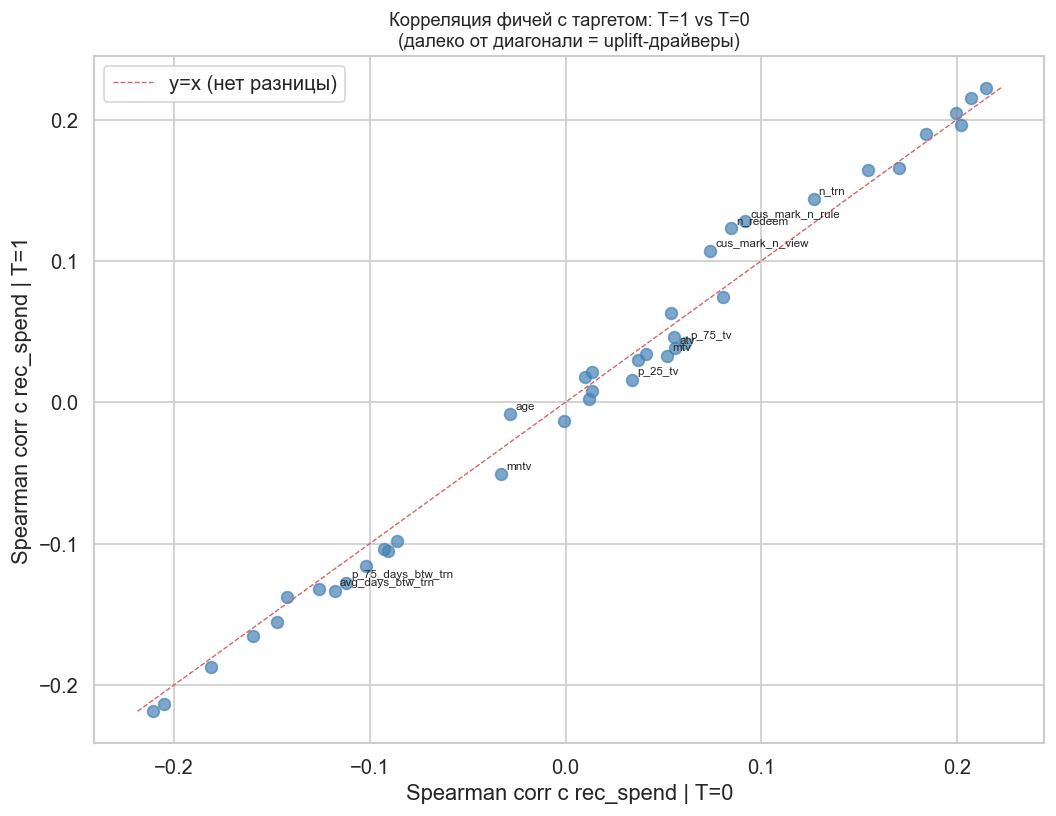

In [14]:
numeric_feats = [c for c in FEATURE_COLS
                 if train[c].dtype in ['float64','int32','int64','float32']
                 and train[c].nunique() > 5]

corr_t1 = (train.loc[train[TREATMENT_COL]==1, numeric_feats + [TARGET_COL]]
               .corrwith(train.loc[train[TREATMENT_COL]==1, TARGET_COL], method='spearman')
               .drop(TARGET_COL))
corr_t0 = (train.loc[train[TREATMENT_COL]==0, numeric_feats + [TARGET_COL]]
               .corrwith(train.loc[train[TREATMENT_COL]==0, TARGET_COL], method='spearman')
               .drop(TARGET_COL))

corr_df = pd.DataFrame({'corr_t1': corr_t1, 'corr_t0': corr_t0})
corr_df['diff_abs'] = (corr_df['corr_t1'] - corr_df['corr_t0']).abs()
corr_df = corr_df.sort_values('diff_abs', ascending=False)
corr_df.to_csv(f'{ARTIFACTS_DIR}/spearman_corr_target.csv')

print('Топ-20 фичей по разнице corr(T=1) vs corr(T=0) — потенциальные uplift-драйверы:')
display(corr_df.head(20).round(4))

fig, ax = plt.subplots(figsize=(9, 7))
pdata = corr_df.head(40).reset_index().rename(columns={'index': 'feature'})
ax.scatter(pdata['corr_t0'], pdata['corr_t1'], s=50, alpha=0.7, color='steelblue')
for _, row in pdata.head(12).iterrows():
    ax.annotate(row['feature'], (row['corr_t0'], row['corr_t1']),
                fontsize=7, xytext=(3,3), textcoords='offset points')
mn_ = min(pdata[['corr_t0','corr_t1']].min())
mx_ = max(pdata[['corr_t0','corr_t1']].max())
ax.plot([mn_, mx_], [mn_, mx_], 'r--', lw=0.8, label='y=x (нет разницы)')
ax.set_xlabel('Spearman corr с rec_spend | T=0')
ax.set_ylabel('Spearman corr с rec_spend | T=1')
ax.set_title('Корреляция фичей с таргетом: T=1 vs T=0\n(далеко от диагонали = uplift-драйверы)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/corr_scatter_t1_vs_t0.png', bbox_inches='tight')
plt.show()


## 10. Treatment-ассоциированные фичи (метод Скалотех)

Обучаем регрессор на `rec_spend` и классификатор на `treatment_flg`.
Фичи из нижних 20% регрессора ∩ топ-20 классификатора — кандидаты на удаление.

In [16]:
train_enc = train.copy()

# Энкодим все строковые/категориальные колонки
le = LabelEncoder()
for col in train_enc[FEATURE_COLS].select_dtypes(include=['object', 'string', 'category']).columns:
    train_enc[col] = le.fit_transform(train_enc[col].astype(str))

X_all = train_enc[FEATURE_COLS].fillna(-999)
y_tgt = train_enc[TARGET_COL]
y_trt = train_enc[TREATMENT_COL]

# Финальная проверка — не должно быть str/object
bad_cols = X_all.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if bad_cols:
    print(f'⚠️  Остались нечисловые колонки, дропаем: {bad_cols}')
    X_all = X_all.drop(columns=bad_cols)
    FEATURE_COLS_ENC = X_all.columns.tolist()
else:
    FEATURE_COLS_ENC = FEATURE_COLS
    print(f'✅ Все фичи числовые: {X_all.shape[1]} колонок')

lgb_params = dict(n_estimators=300, learning_rate=0.05, num_leaves=63,
                  random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

reg_model = lgb.LGBMRegressor(**lgb_params)
reg_model.fit(X_all, y_tgt)

clf_model = lgb.LGBMClassifier(**lgb_params)
clf_model.fit(X_all, y_trt)

reg_imp   = pd.Series(reg_model.feature_importances_, index=FEATURE_COLS_ENC)
clf_imp   = pd.Series(clf_model.feature_importances_, index=FEATURE_COLS_ENC)
reg_imp_n = reg_imp / reg_imp.sum()
clf_imp_n = clf_imp / clf_imp.sum()

n_feats = len(FEATURE_COLS_ENC)
bottom20_reg    = set(reg_imp_n.nsmallest(int(n_feats * 0.2)).index)
top20_clf       = set(clf_imp_n.nlargest(20).index)
treatment_assoc = bottom20_reg & top20_clf

imp_df = pd.DataFrame({
    'feature':              FEATURE_COLS_ENC,
    'reg_imp_norm':         reg_imp_n.values,
    'clf_imp_norm':         clf_imp_n.values,
    'treatment_associated': [f in treatment_assoc for f in FEATURE_COLS_ENC]
}).sort_values('reg_imp_norm', ascending=False)
imp_df.to_csv(f'{ARTIFACTS_DIR}/treatment_associated_features.csv', index=False)

print(f'Всего фичей: {n_feats}')
print(f'Treatment-associated (удалить): {len(treatment_assoc)}')
for f in sorted(treatment_assoc):
    print(f'  {f}: {feat_desc.get(f, "")}')

✅ Все фичи числовые: 86 колонок
Всего фичей: 86
Treatment-associated (удалить): 0


In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADVERSARIAL VALIDATION — полная ячейка (gain everywhere)
# ═══════════════════════════════════════════════════════════════════════════════
import warnings, os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, gaussian_kde
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score

warnings.filterwarnings('ignore')
os.makedirs(f'{ARTIFACTS_DIR}/adversarial', exist_ok=True)

FEAT_COLS_ADV = best_feat_xl

# ── Хелпер: gain importance через booster напрямую ───────────────────────────
def get_gain_importance(clf, feat_cols):
    """Всегда возвращает gain — надёжнее чем feature_importances_"""
    raw = clf.booster_.feature_importance(importance_type='gain')
    return pd.DataFrame({
        'feature':    feat_cols,
        'importance': raw
    }).sort_values('importance', ascending=False).reset_index(drop=True)

# ── 1. Подготовка объединённого датасета ─────────────────────────────────────
train_adv = train[FEAT_COLS_ADV].copy(); train_adv['_is_test'] = 0
test_adv  = test[FEAT_COLS_ADV].copy();  test_adv['_is_test']  = 1

df_adv   = pd.concat([train_adv, test_adv], ignore_index=True)
X_adv    = encode_X(df_adv, FEAT_COLS_ADV)
y_adv    = df_adv['_is_test'].values
X_adv_np = X_adv.values if hasattr(X_adv, 'values') else np.array(X_adv)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── 2. ROC-AUC curves (5-fold) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
oof_probs = np.zeros(len(X_adv_np))
tprs, aucs_list = [], []
mean_fpr = np.linspace(0, 1, 300)

for fold_i, (tr_idx, val_idx) in enumerate(cv.split(X_adv_np, y_adv)):
    clf_fold = lgb.LGBMClassifier(
        n_estimators=300, num_leaves=63, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    )
    clf_fold.fit(X_adv_np[tr_idx], y_adv[tr_idx])
    raw_probs = clf_fold.predict_proba(X_adv_np[val_idx])[:, 1]
    # Инвертируем если классификатор перепутал классы местами
    probs = raw_probs if np.mean(raw_probs[y_adv[val_idx] == 1]) > 0.5 else 1 - raw_probs
    oof_probs[val_idx] = probs

    fpr, tpr, _ = roc_curve(y_adv[val_idx], probs)
    fold_auc = auc(fpr, tpr)
    aucs_list.append(fold_auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    ax.plot(fpr, tpr, alpha=0.25, linewidth=1, color='#3498db',
            label=f'Fold {fold_i+1} (AUC={fold_auc:.3f})')

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[0] = 0.0; mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs_list)
std_auc  = np.std(aucs_list)
std_tpr  = np.std(tprs, axis=0)

ax.plot(mean_fpr, mean_tpr, color='#e74c3c', linewidth=2.5,
        label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})', zorder=5)
ax.fill_between(mean_fpr,
                np.clip(mean_tpr - std_tpr, 0, 1),
                np.clip(mean_tpr + std_tpr, 0, 1),
                alpha=0.15, color='#e74c3c', label='±1 std')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        linewidth=1.5, label='Random (AUC = 0.500)', zorder=1)

if mean_auc < 0.55:
    interp_text = '✅ Нет значимого shift\n(распределения похожи)'
    interp_color = '#27ae60'
elif mean_auc < 0.65:
    interp_text = '⚠️ Умеренный shift\n(стоит изучить топ-фичи)'
    interp_color = '#e67e22'
else:
    interp_text = '❌ Сильный shift\n(модель может деградировать)'
    interp_color = '#c0392b'

ax.text(0.57, 0.12, interp_text, transform=ax.transAxes,
        fontsize=11, color=interp_color, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=interp_color, alpha=0.9))
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Adversarial Validation: Train vs Test\n(LightGBM, 5-fold CV)', fontsize=13)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/adversarial/roc_auc_adversarial.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'✅ ROC saved  |  Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}')

# ── 3. Обучаем clf_adv на ПОЛНОМ датасете — для gain importance и SHAP ────────
clf_adv = lgb.LGBMClassifier(
    n_estimators=300, num_leaves=63, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
)
clf_adv.fit(X_adv_np, y_adv)

# Gain через booster — единственный надёжный способ
adv_importance = get_gain_importance(clf_adv, FEAT_COLS_ADV)
print(f'\nTop-15 features by GAIN importance (adversarial):')
print(adv_importance.head(15).to_string(index=False, float_format='{:.2f}'.format))

# ── 4. KS-тест ───────────────────────────────────────────────────────────────
ks_results = []
for col in FEAT_COLS_ADV:
    stat, pval = ks_2samp(train[col].dropna().values, test[col].dropna().values)
    ks_results.append({'feature': col, 'ks_stat': stat, 'ks_pval': pval})
ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False).reset_index(drop=True)
ks_df['significant'] = ks_df['ks_pval'] < 0.01

print('\nTop-15 features by KS statistic:')
print(ks_df.head(15).to_string(index=False, float_format='{:.4f}'.format))

# ── 5. Двойная панель: Gain importance + KS ──────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 8))

top25_adv = adv_importance.head(25)
axes2[0].barh(top25_adv['feature'][::-1], top25_adv['importance'][::-1],
              color='#e05c5c', alpha=0.85)
axes2[0].axvline(top25_adv['importance'].mean(), color='gray',
                 linestyle='--', alpha=0.5, label='mean')
axes2[0].set_xlabel('Gain Importance (adversarial LGB)')
axes2[0].set_title(f'Adversarial Feature Importance (Gain)\nAUC={mean_auc:.4f}')
axes2[0].legend()

top25_ks = ks_df.head(25)
colors_ks = ['#c0392b' if s else '#5dade2' for s in top25_ks['significant']]
axes2[1].barh(top25_ks['feature'][::-1], top25_ks['ks_stat'][::-1],
              color=colors_ks[::-1], alpha=0.85)
axes2[1].axvline(0.05, color='gray', linestyle='--', alpha=0.5, label='KS=0.05')
axes2[1].set_xlabel('KS Statistic')
axes2[1].set_title('KS Test: train vs test\n(красный = p<0.01)')
axes2[1].legend()

plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/adversarial/adv_importance_ks.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: adv_importance_ks.png')

# ── 6. Ранжируем по gain, строим distribution plots топ-16 ───────────────────
# avg_rank только по gain (как и просили — только gain для значимости)
combined = adv_importance.merge(ks_df, on='feature')
combined['gain_rank'] = combined['importance'].rank(ascending=False)
combined = combined.sort_values('gain_rank').reset_index(drop=True)
TOP_SHIFT = combined.head(16)['feature'].tolist()

fig3, axes3 = plt.subplots(4, 4, figsize=(20, 16))
axes3 = axes3.flatten()
TOP_SHIFT[-1] = "mtv"
for i, feat in enumerate(TOP_SHIFT):
    ax = axes3[i]
    tr_vals = train[feat].dropna().values
    te_vals = test[feat].dropna().values
    ks_val  = ks_df.loc[ks_df['feature'] == feat, 'ks_stat'].values[0]
    gain_val = adv_importance.loc[adv_importance['feature'] == feat, 'importance'].values[0]

    if pd.Series(tr_vals).nunique() <= 15:
        tr_norm = pd.Series(tr_vals).value_counts(normalize=True).sort_index()
        te_norm = pd.Series(te_vals).value_counts(normalize=True).sort_index()
        idx = sorted(set(tr_norm.index) | set(te_norm.index))
        x = range(len(idx))
        ax.bar([xi - 0.2 for xi in x], [tr_norm.get(v, 0) for v in idx],
               width=0.4, label='train', color='#3498db', alpha=0.7)
        ax.bar([xi + 0.2 for xi in x], [te_norm.get(v, 0) for v in idx],
               width=0.4, label='test', color='#e74c3c', alpha=0.7)
        ax.set_xticks(list(x)); ax.set_xticklabels(idx, rotation=45, fontsize=7)
    else:
        lo = min(np.quantile(tr_vals, 0.01), np.quantile(te_vals, 0.01))
        hi = max(np.quantile(tr_vals, 0.99), np.quantile(te_vals, 0.99))
        xs = np.linspace(lo, hi, 300)
        tr_c = tr_vals[(tr_vals >= lo) & (tr_vals <= hi)]
        te_c = te_vals[(te_vals >= lo) & (te_vals <= hi)]
        try:
            kde_tr = gaussian_kde(tr_c, bw_method=0.3)
            kde_te = gaussian_kde(te_c, bw_method=0.3)
            ax.plot(xs, kde_tr(xs), color='#3498db', linewidth=2, label='train')
            ax.plot(xs, kde_te(xs), color='#e74c3c', linewidth=2,
                    linestyle='--', label='test')
            ax.fill_between(xs, kde_tr(xs), alpha=0.15, color='#3498db')
            ax.fill_between(xs, kde_te(xs), alpha=0.15, color='#e74c3c')
        except Exception:
            ax.hist(tr_c, bins=30, density=True, alpha=0.5, color='#3498db', label='train')
            ax.hist(te_c, bins=30, density=True, alpha=0.5, color='#e74c3c', label='test')

    ax.set_title(f'{feat}\nGain={gain_val:.0f}  KS={ks_val:.3f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_ylabel('')

plt.suptitle('Train vs Test: Top-16 by Gain Importance', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/adversarial/distribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: distribution_shift.png')

# ── 7. По группам communication_type ─────────────────────────────────────────
print('\n─── Adversarial AUC by communication_type (gain-based) ───')
for ct in sorted(train['communication_type'].unique()):
    tr_ct = train[train['communication_type'] == ct][FEAT_COLS_ADV].copy()
    te_ct = test[test['communication_type'] == ct][FEAT_COLS_ADV].copy()
    if len(te_ct) < 100 or len(tr_ct) < 100:
        print(f'  type={ct}: skipped (too few samples)'); continue
    tr_ct['_is_test'] = 0; te_ct['_is_test'] = 1
    df_ct   = pd.concat([tr_ct, te_ct], ignore_index=True)
    X_ct    = encode_X(df_ct, FEAT_COLS_ADV)
    X_ct_np = X_ct.values if hasattr(X_ct, 'values') else np.array(X_ct)
    y_ct    = df_ct['_is_test'].values
    fold_aucs = []
    for tr_i, val_i in StratifiedKFold(n_splits=3, shuffle=True,
                                        random_state=RANDOM_STATE).split(X_ct_np, y_ct):
        clf_ct = lgb.LGBMClassifier(n_estimators=200, num_leaves=31,
                                     n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
        clf_ct.fit(X_ct_np[tr_i], y_ct[tr_i])
        raw = clf_ct.predict_proba(X_ct_np[val_i])[:, 1]
        p = raw if np.mean(raw[y_ct[val_i] == 1]) > 0.5 else 1 - raw
        fold_aucs.append(roc_auc_score(y_ct[val_i], p))
    auc_ct = np.mean(fold_aucs)
    flag = '✅' if auc_ct < 0.55 else ('⚠️' if auc_ct < 0.65 else '❌')
    # Gain importance для этого канала
    clf_ct_full = lgb.LGBMClassifier(n_estimators=200, num_leaves=31,
                                      n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
    clf_ct_full.fit(X_ct_np, y_ct)
    ct_gain = get_gain_importance(clf_ct_full, FEAT_COLS_ADV)
    top3 = ', '.join(ct_gain.head(3)['feature'].tolist())
    print(f'  type={ct}: AUC={auc_ct:.4f}  {flag}  | top-3 gain: [{top3}]')

# Сохраняем
ks_df.to_csv(f'{ARTIFACTS_DIR}/adversarial/ks_results.csv', index=False)
combined.to_csv(f'{ARTIFACTS_DIR}/adversarial/combined_shift_rank.csv', index=False)
adv_importance.to_csv(f'{ARTIFACTS_DIR}/adversarial/gain_importance.csv', index=False)
print('\n✅ All adversarial artifacts saved')

NameError: name 'best_feat_xl' is not defined

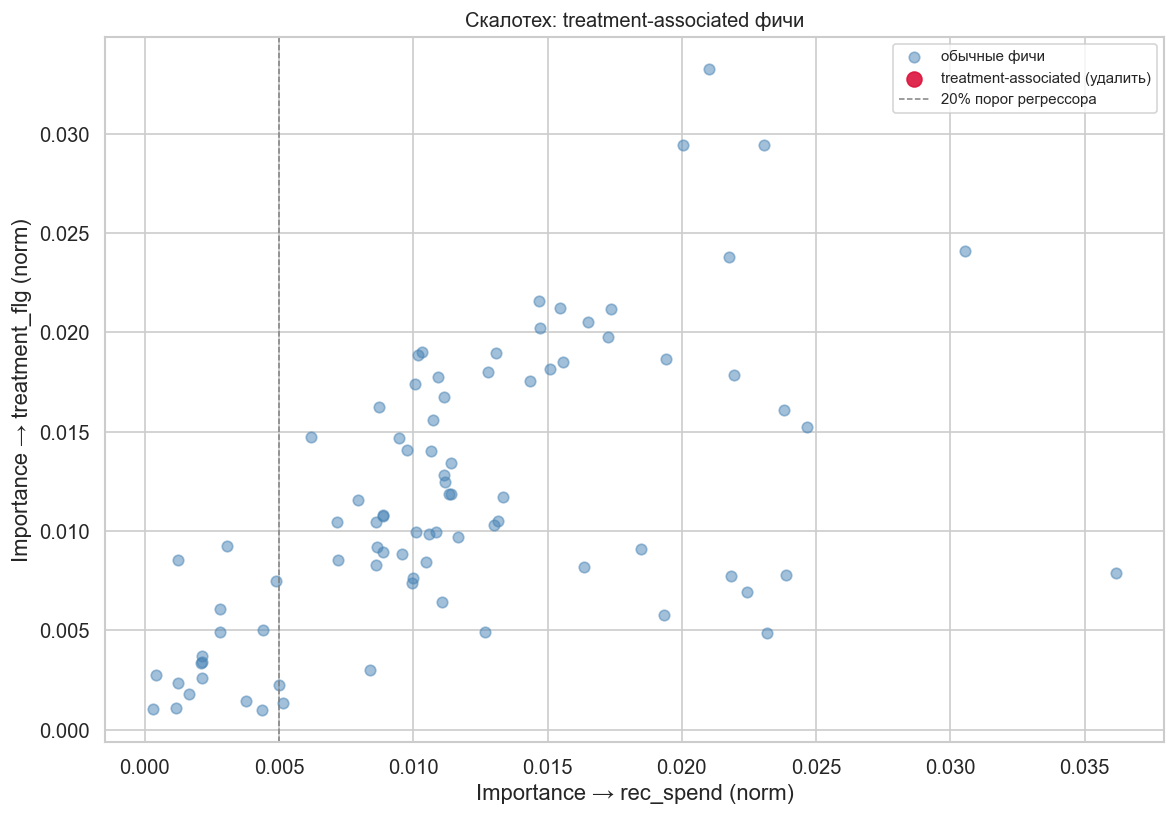

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
non_a = imp_df[~imp_df['treatment_associated']]
assoc = imp_df[imp_df['treatment_associated']]
ax.scatter(non_a['reg_imp_norm'], non_a['clf_imp_norm'],
           s=40, alpha=0.5, color='steelblue', label='обычные фичи')
ax.scatter(assoc['reg_imp_norm'], assoc['clf_imp_norm'],
           s=80, alpha=0.9, color='crimson', zorder=5, label='treatment-associated (удалить)')
for _, row in assoc.iterrows():
    ax.annotate(row['feature'], (row['reg_imp_norm'], row['clf_imp_norm']),
                fontsize=7, color='crimson', xytext=(3,3), textcoords='offset points')
ax.axvline(reg_imp_n.quantile(0.2), color='gray', ls='--', lw=0.9,
           label=f'20% порог регрессора')
ax.set_xlabel('Importance → rec_spend (norm)')
ax.set_ylabel('Importance → treatment_flg (norm)')
ax.set_title('Скалотех: treatment-associated фичи', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/treatment_associated_scatter.png', bbox_inches='tight')
plt.show()


## 11. Baseline T-learner: Feature Importance + SHAP

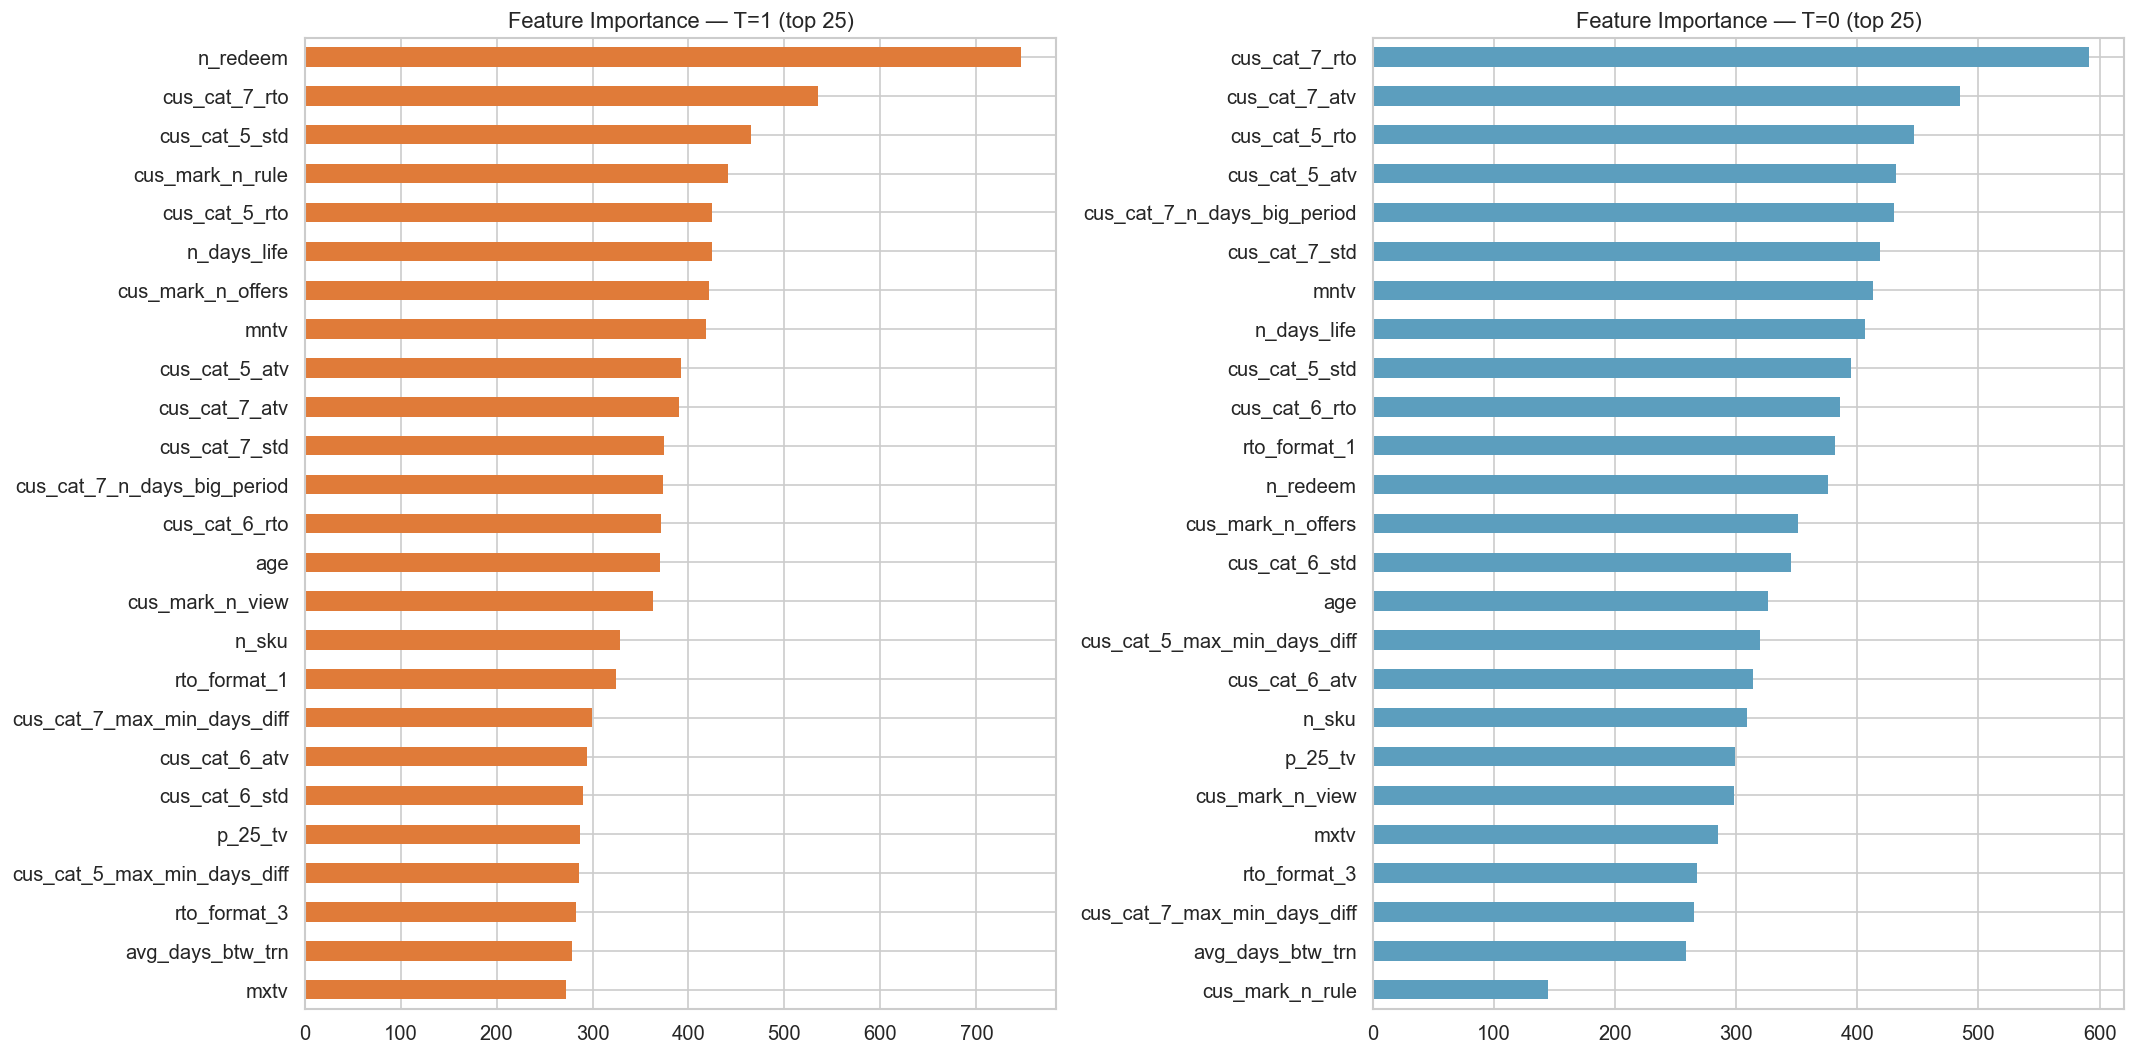

Top-15 фичей по fi_mean:


,fi_t1,fi_t0,fi_mean
cus_cat_7_rto,535,591,563.0
n_redeem,746,376,561.0
cus_cat_7_atv,390,485,437.5
cus_cat_5_rto,425,447,436.0
cus_cat_5_std,465,395,430.0
mntv,418,413,415.5
n_days_life,425,406,415.5
cus_cat_5_atv,392,432,412.0
cus_cat_7_n_days_big_period,373,430,401.5
cus_cat_7_std,375,419,397.0


In [18]:
idx_t1 = train_enc[TREATMENT_COL] == 1
idx_t0 = train_enc[TREATMENT_COL] == 0

lgb_t1 = lgb.LGBMRegressor(**lgb_params)
lgb_t0 = lgb.LGBMRegressor(**lgb_params)
lgb_t1.fit(X_all[idx_t1], y_tgt[idx_t1])
lgb_t0.fit(X_all[idx_t0], y_tgt[idx_t0])

fi_t1 = pd.Series(lgb_t1.feature_importances_, index=FEATURE_COLS)
fi_t0 = pd.Series(lgb_t0.feature_importances_, index=FEATURE_COLS)
fi_df = pd.DataFrame({'fi_t1': fi_t1, 'fi_t0': fi_t0})
fi_df['fi_mean'] = (fi_df['fi_t1'] + fi_df['fi_t0']) / 2
fi_df = fi_df.sort_values('fi_mean', ascending=False)
fi_df.to_csv(f'{ARTIFACTS_DIR}/baseline_feature_importance.csv')

top_k = 25
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fi_df.head(top_k)['fi_t1'].sort_values().plot(
    kind='barh', ax=axes[0], color='#e07b39', edgecolor='none')
axes[0].set_title(f'Feature Importance — T=1 (top {top_k})')
fi_df.head(top_k)['fi_t0'].sort_values().plot(
    kind='barh', ax=axes[1], color='#5c9ebe', edgecolor='none')
axes[1].set_title(f'Feature Importance — T=0 (top {top_k})')
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/feature_importance_tlearner.png', bbox_inches='tight')
plt.show()
print('Top-15 фичей по fi_mean:')
display(fi_df.head(15).round(1))


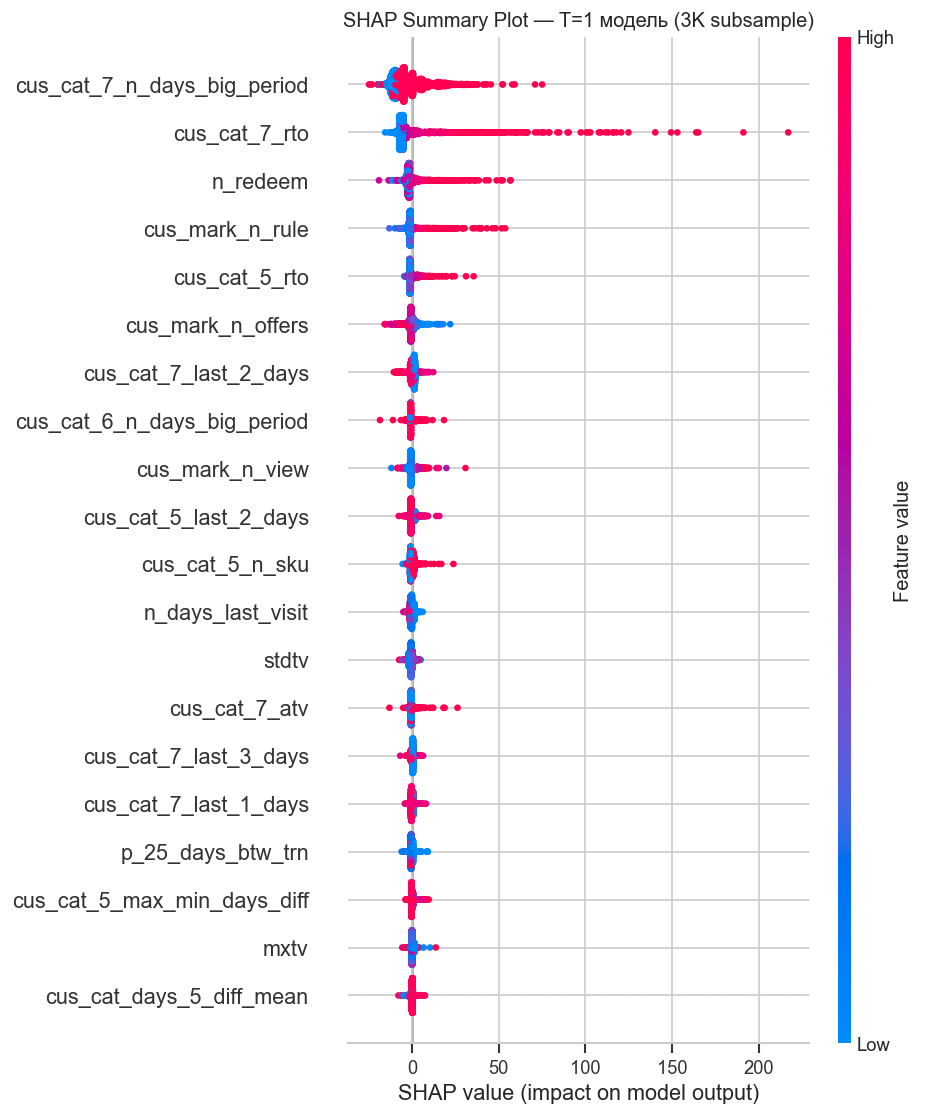

In [19]:
sample_idx = X_all.sample(min(3000, len(X_all)), random_state=RANDOM_STATE).index
explainer = shap.TreeExplainer(lgb_t1)
shap_vals = explainer.shap_values(X_all.loc[sample_idx])

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_all.loc[sample_idx], max_display=20, show=False)
plt.title('SHAP Summary Plot — T=1 модель (3K subsample)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/shap_summary_t1.png', bbox_inches='tight')
plt.show()


## 12. Baseline uplift-кривые

In [22]:
from sklift.metrics import uplift_at_k, qini_auc_score
from sklift.viz import plot_uplift_curve, plot_qini_curve

ImportError: cannot import name 'check_matplotlib_support' from 'sklearn.utils' (/Users/olegandreev/Downloads/Кейс 2. Uplift/.venv/lib/python3.14/site-packages/sklearn/utils/__init__.py)

Baseline uplift@10 (train!): 0.3879  ← оптимистичная оценка
Baseline Qini AUC:           0.3788
Baseline Qini AUC norm:      0.0002
⚠️  Для честной оценки нужен OOF — делаем в пилоте!


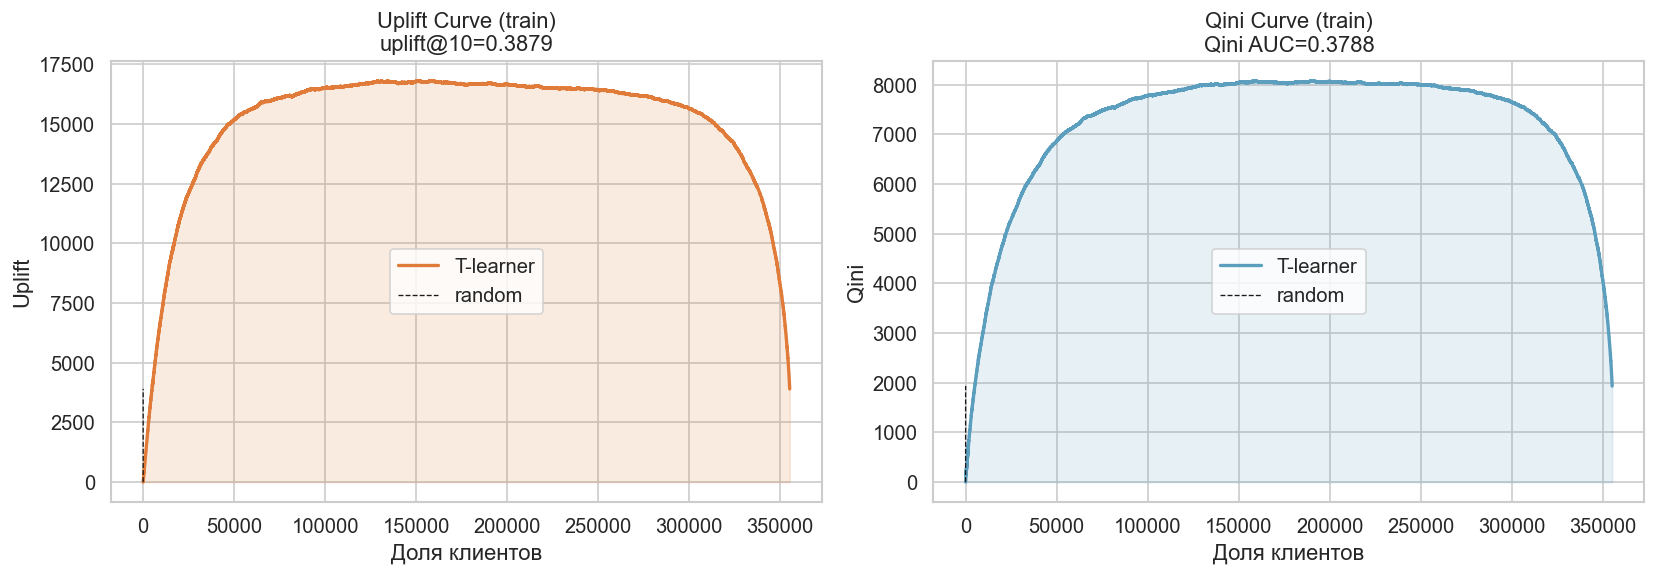

In [25]:
from sklift.metrics import uplift_at_k, qini_auc_score
from sklift.metrics import uplift_curve, qini_curve, perfect_qini_curve

uplift_score = lgb_t1.predict(X_all) - lgb_t0.predict(X_all)
y_binary = (y_tgt > 0).astype(int)

u10  = uplift_at_k(y_binary, uplift_score, y_trt, strategy='overall', k=0.1)
qauc = qini_auc_score(y_binary, uplift_score, y_trt)  # без normalize
# Нормализуем вручную: делим на площадь идеальной кривой
_, perfect_qini = perfect_qini_curve(y_binary, y_trt)
qauc_norm = qauc / perfect_qini[-1] if perfect_qini[-1] != 0 else qauc

print(f'Baseline uplift@10 (train!): {u10:.4f}  ← оптимистичная оценка')
print(f'Baseline Qini AUC:           {qauc:.4f}')
print(f'Baseline Qini AUC norm:      {qauc_norm:.4f}')
print('⚠️  Для честной оценки нужен OOF — делаем в пилоте!')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n, uplift_vals = uplift_curve(y_binary, uplift_score, y_trt)
axes[0].plot(n, uplift_vals, color='#e07b39', lw=2, label='T-learner')
axes[0].plot([0, 1], [0, uplift_vals[-1]], 'k--', lw=0.8, label='random')
axes[0].fill_between(n, uplift_vals, alpha=0.15, color='#e07b39')
axes[0].set_title(f'Uplift Curve (train)\nuplift@10={u10:.4f}')
axes[0].set_xlabel('Доля клиентов'); axes[0].set_ylabel('Uplift')
axes[0].legend()

n_q, qini_vals = qini_curve(y_binary, uplift_score, y_trt)
axes[1].plot(n_q, qini_vals, color='#5c9ebe', lw=2, label='T-learner')
axes[1].plot([0, 1], [0, qini_vals[-1]], 'k--', lw=0.8, label='random')
axes[1].fill_between(n_q, qini_vals, alpha=0.15, color='#5c9ebe')
axes[1].set_title(f'Qini Curve (train)\nQini AUC={qauc:.4f}')
axes[1].set_xlabel('Доля клиентов'); axes[1].set_ylabel('Qini')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/baseline_uplift_curves.png', bbox_inches='tight')
plt.show()

with open(f'{ARTIFACTS_DIR}/baseline_metrics.json', 'w') as f:
    json.dump({
        'uplift_at_10_train': float(u10),
        'qini_auc_train': float(qauc),
        'qini_auc_norm_train': float(qauc_norm)
    }, f, indent=2)

## 13. Сохранение финального конфига для пилота

In [26]:
clean_features = [f for f in FEATURE_COLS if f not in treatment_assoc]
print(f'Финальный набор фичей: {len(clean_features)} (было {len(FEATURE_COLS)})')

feature_config = {
    'all_features':    FEATURE_COLS,
    'treatment_associated_features': sorted(treatment_assoc),
    'clean_features':  clean_features,
    'top25_by_importance': fi_df.head(25).index.tolist(),
    'comm_types': [str(c) for c in comm_types],
    'target_col':    TARGET_COL,
    'treatment_col': TREATMENT_COL,
    'comm_col':      COMM_COL,
    'id_col':        ID_COL,
    'random_state':  RANDOM_STATE,
    'separate_models_by_comm_type': bool(
        uplift_comm_df['uplift_mean'].max() - uplift_comm_df['uplift_mean'].min() > 0.01
    ),
}
with open(f'{ARTIFACTS_DIR}/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print('\n✅ Артефакты в папке:', ARTIFACTS_DIR)
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    sz = os.path.getsize(f'{ARTIFACTS_DIR}/{fname}')
    print(f'  {fname:<55s} {sz:>8,} bytes')


Финальный набор фичей: 86 (было 86)

✅ Артефакты в папке: eda_artifacts
  baseline_feature_importance.csv                            2,681 bytes
  baseline_metrics.json                                        136 bytes
  baseline_uplift_curves.png                                76,206 bytes
  corr_scatter_t1_vs_t0.png                                 71,805 bytes
  describe_stats.csv                                         9,482 bytes
  feature_config.json                                        5,137 bytes
  feature_distributions_tc.png                             156,321 bytes
  feature_importance_tlearner.png                          122,816 bytes
  global_stats.json                                            367 bytes
  hypothesis1_comm_type.json                                 1,311 bytes
  hypothesis2_segments.json                                  7,235 bytes
  ks_test_tc_balance.csv                                       548 bytes
  null_counts.csv                                   

In [27]:
print('=' * 65)
print('EDA SUMMARY  — передай папку eda_artifacts/ для пилота')
print('=' * 65)

with open(f'{ARTIFACTS_DIR}/global_stats.json') as f:
    gs = json.load(f)

print(f"Train: {gs['n_train']:,} | Test: {gs['n_test']:,}")
print(f"Treatment / Control: {gs['n_treatment']:,} / {gs['n_control']:,}")
print(f"Нули в rec_spend: {gs['target_zero_pct']:.1f}% "
      f"(T1: {gs['target_zero_pct_t1']:.1f}%, T0: {gs['target_zero_pct_t0']:.1f}%)")
print(f"Raw global uplift: {gs['raw_global_uplift']:.4f}  (p={gs['mannwhitney_p']:.2e})")
print()
print(f"Treatment-associated (удалить): {sorted(treatment_assoc)}")
print(f"Чистых фичей: {len(clean_features)}")
print()
print('Аплифт по каналам:')
for r in uplift_comm_df.itertuples():
    print(f'  {r.communication_type}: {r.uplift_mean:.4f} [{r.ci80_lo:.4f}, {r.ci80_hi:.4f}]')
print()
print('Гетерогенность по сегментам:')
for sc, data in hyp2.items():
    print(f'  {sc}: range={data["uplift_range"]:.4f} → {data["heterogeneity"]}')


EDA SUMMARY  — передай папку eda_artifacts/ для пилота
Train: 355,246 | Test: 118,414
Treatment / Control: 176,032 / 179,214
Нули в rec_spend: 90.2% (T1: 89.6%, T0: 90.7%)
Raw global uplift: 3.1895  (p=8.43e-30)

Treatment-associated (удалить): []
Чистых фичей: 86

Аплифт по каналам:
  com_type_1: 3.7781 [3.2742, 4.3455]
  com_type_2: 1.4226 [0.8624, 2.0480]
  com_type_3: 4.3724 [3.7668, 5.0094]

Гетерогенность по сегментам:
  rto_segment: range=3.3618 → HIGH
  cat7_seg: range=2.7492 → HIGH
  recency_seg: range=3.9009 → HIGH
  age_seg: range=5.3114 → HIGH
  mkt_seg: range=8.6976 → HIGH


In [28]:
import json, os

# Читаем все нужные артефакты
artifacts = {}
artifacts_dir = 'eda_artifacts'

# JSON-файлы
json_files = [
    'global_stats.json',
    'feature_config.json',
    'hypothesis1_comm_type.json',
    'hypothesis2_segments.json',
    'baseline_metrics.json',
]
for fname in json_files:
    fpath = f'{artifacts_dir}/{fname}'
    if os.path.exists(fpath):
        with open(fpath) as f:
            artifacts[fname] = json.load(f)

# CSV-файлы → сохраняем как строки
csv_files = [
    'null_counts.csv',
    'describe_stats.csv',
    'uplift_by_comm_type.csv',
    'treatment_associated_features.csv',
    'baseline_feature_importance.csv',
    'spearman_corr_target.csv',
    'ks_test_tc_balance.csv',
    'tc_balance_by_comm_type.csv',
]
for fname in csv_files:
    fpath = f'{artifacts_dir}/{fname}'
    if os.path.exists(fpath):
        with open(fpath) as f:
            artifacts[fname] = f.read()

# Сегменты по папке
for fname in os.listdir(artifacts_dir):
    if fname.startswith('uplift_seg_') and fname.endswith('.csv'):
        with open(f'{artifacts_dir}/{fname}') as f:
            artifacts[fname] = f.read()

# Сохраняем всё в один JSON
output_path = 'eda_summary_for_pilot.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(artifacts, f, ensure_ascii=False, indent=2, default=str)

size_kb = os.path.getsize(output_path) / 1024
print(f'✅ Сохранено: {output_path}  ({size_kb:.1f} KB)')
print(f'Содержит {len(artifacts)} артефактов:')
for k in artifacts:
    print(f'  {k}')

✅ Сохранено: eda_summary_for_pilot.json  (47.6 KB)
Содержит 18 артефактов:
  global_stats.json
  feature_config.json
  hypothesis1_comm_type.json
  hypothesis2_segments.json
  baseline_metrics.json
  null_counts.csv
  describe_stats.csv
  uplift_by_comm_type.csv
  treatment_associated_features.csv
  baseline_feature_importance.csv
  spearman_corr_target.csv
  ks_test_tc_balance.csv
  tc_balance_by_comm_type.csv
  uplift_seg_mkt_seg.csv
  uplift_seg_recency_seg.csv
  uplift_seg_age_seg.csv
  uplift_seg_cat7_seg.csv
  uplift_seg_rto_segment.csv
